# EDA: Consequence-Based BED Delta Score Distributions

**Purpose**: Analyze NTv3 BED track delta distributions for genomic variants grouped by molecular consequences (splicing, truncation, missense, regulatory, etc.) and pathogenicity label.

**Data sources**:
- `data/stav_data/stav data/annotated_snps_signaled.parquet` (SNPs with NTv3 deltas + annotations)
- `data/stav_data/stav data/annotated_indels_signaled.parquet` (INDELs with NTv3 deltas + annotations)

**Analyses**:
1. Regex-based consequence grouping from `FullRationale` ClinVar text
2. BED element delta distributions (KDE plots) per consequence × pathogenicity label
3. Structural region grouping via `region_class`
4. MLM feature distributions (`LLR`, `MLM_Delta`, `MLM_KL`) across the full dataset

**Output**: Publication-quality figures (300 DPI)

High-level checkpoints

- Confirm label mapping happens before regex matching.
- Review consequence-group coverage and overlap.
- Only render a label KDE when it has at least 10 cases.
- Spot-check exported PDFs for readability and scale.


In [1]:
# ============================================================================
# SETUP & IMPORTS
# ============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import warnings
from pathlib import Path
from scipy import stats

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# ============================================================================
# PUBLICATION-QUALITY PLOTTING CONFIGURATION
# ============================================================================
# Set seaborn style and context
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# Matplotlib defaults for publication
plt.rcParams.update(
    {
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.format": "pdf",
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,  # TrueType fonts for editing
        "ps.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Color palette for Pathogenic/Benign
LABEL_COLORS = {
    "Pathogenic": "#d73027",  # Red
    "Benign": "#4575b4",  # Blue
}

# Output directory for figures
FIG_DIR = Path("analyses/figures/eda_consequence_distributions")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Setup complete")
print(f"📊 Figure output directory: {FIG_DIR}")
print(f"🎨 Plotting style: {sns.axes_style()['axes.facecolor']}")

✅ Setup complete
📊 Figure output directory: analyses/figures/eda_consequence_distributions
🎨 Plotting style: white


In [ ]:
# ============================================================================
# LOAD & COMBINE DATA (SNPs + INDELs)
# ============================================================================
print("📂 Loading data...")

# Load SNPs
snp_path = "data/stav_data/stav data/annotated_snps_signaled.parquet"
df_snps = pd.read_parquet(snp_path)
df_snps["variant_type"] = "SNP"
print(f"   SNPs: {len(df_snps):,} variants")

# Load INDELs
indel_path = "data/stav_data/stav data/annotated_indels_signaled.parquet"
df_indels = pd.read_parquet(indel_path)
df_indels["variant_type"] = "INDEL"
print(f"   INDELs: {len(df_indels):,} variants")

# Combine
df = pd.concat([df_snps, df_indels], ignore_index=True)
print(f"\n✅ Combined dataset: {len(df):,} variants × {df.shape[1]:,} columns")

# FIX: Map boolean labels to strings for easier plotting and interpretation
if set(df["label"].dropna().unique()).issubset({True, False, 1, 0}):
    print("🔄 Converting boolean labels to 'Pathogenic' / 'Benign' strings")
    df["label"] = df["label"].astype(bool).map({True: "Pathogenic", False: "Benign"})

# Label distribution
label_counts = df["label"].value_counts()
print(f"\n📊 Label distribution:")
for label, count in label_counts.items():
    pct = 100 * count / len(df)
    print(f"   {label}: {count:,} ({pct:.1f}%)")

# Variant type distribution
vtype_counts = df["variant_type"].value_counts()
print(f"\n📊 Variant type distribution:")
for vtype, count in vtype_counts.items():
    pct = 100 * count / len(df)
    print(f"   {vtype}: {count:,} ({pct:.1f}%)")

# Cross-tabulation
print(f"\n📊 Label × Variant Type:")
print(pd.crosstab(df["label"], df["variant_type"], margins=True))

# Check for FullRationale column
if "FullRationale" not in df.columns:
    print("\n⚠️  WARNING: 'FullRationale' column not found!")
    print(
        f"   Available text columns: {[c for c in df.columns if df[c].dtype == 'object'][:10]}"
    )
else:
    # Count variants with/without rationale
    has_rationale = (
        ~df["FullRationale"].isna()
        & (df["FullRationale"] != "")
        & ~df["FullRationale"].str.contains("No.*rationale", case=False, na=False)
    )
    print(
        f"\n📝 FullRationale coverage: {has_rationale.sum():,} / {len(df):,} ({100 * has_rationale.mean():.1f}%)"
    )

df.head(3)

📂 Loading data...
   SNPs: 9,786 variants
   INDELs: 12,301 variants

✅ Combined dataset: 22,087 variants × 7,340 columns
🔄 Converting boolean labels to 'Pathogenic' / 'Benign' strings

📊 Label distribution:
   Pathogenic: 18,697 (84.7%)
   Benign: 3,390 (15.3%)

📊 Variant type distribution:
   INDEL: 12,301 (55.7%)
   SNP: 9,786 (44.3%)

📊 Label × Variant Type:
variant_type  INDEL   SNP    All
label                           
Benign          536  2854   3390
Pathogenic    11765  6932  18697
All           12301  9786  22087

📝 FullRationale coverage: 22,085 / 22,087 (100.0%)


,chrom,pos,ref,alt,label,GPN-MSA,CADD,phyloP-100v,phyloP-241m,phastCons-100v,...,review_status,MLM_MLM_KL_mean,MLM_MLM_KL_max,MLM_MLM_logprob_ref,MLM_MLM_logprob_alt,MLM_MLM_logprob_delta,MLM_EMB_cosine_dist,MLM_EMB_l2_dist,MLM_EMB_max_pos_dist,MLM_EMB_mean_pos_dist
0,chr1,1014228,G,A,Benign,-2.003906,-0.027262,0.396,0.787,-0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1,1050449,G,A,Pathogenic,-3.966797,-3.882619,-5.271,-6.861,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chr1,1211917,G,A,Benign,-0.191895,-0.013032,0.135,0.028,-0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ============================================================================
# VALIDATE BED DELTA COLUMNS
# ============================================================================
print("🔍 Validating BED delta columns...")

# Define expected BED elements (from config.json bed_elements_names)
BED_ELEMENTS = [
    "protein_coding_gene",
    "lncRNA",
    "exon",
    "intron",
    "splice_donor",
    "splice_acceptor",
    "CTCF-bound",
    "polyA_signal",
    "enhancer_Tissue_specific",
    "enhancer_Tissue_invariant",
    "promoter_Tissue_specific",
    "promoter_Tissue_invariant",
    "5UTR+",
    "5UTR-",
    "3UTR+",
    "3UTR-",
    "skipped_exon",
    "always_on_exon",
    "start_codon",
    "stop_codon",
    "ORF",
]

# Generate expected column names
BED_DELTA_COLS = [f"D_BED_{elem}" for elem in BED_ELEMENTS]

# Check which exist in dataframe
existing_bed_cols = [col for col in BED_DELTA_COLS if col in df.columns]
missing_bed_cols = [col for col in BED_DELTA_COLS if col not in df.columns]

print(f"\n✅ Found {len(existing_bed_cols)} / {len(BED_DELTA_COLS)} BED delta columns")

if missing_bed_cols:
    print(f"\n⚠️  Missing BED columns ({len(missing_bed_cols)}):")
    for col in missing_bed_cols[:5]:
        print(f"   - {col}")
    if len(missing_bed_cols) > 5:
        print(f"   ... and {len(missing_bed_cols) - 5} more")

# Summary statistics for BED deltas
print(f"\n📊 BED Delta Summary Statistics (first 5 columns):")
bed_stats = df[existing_bed_cols[:5]].describe().T
bed_stats["null_count"] = df[existing_bed_cols[:5]].isnull().sum()
bed_stats["null_pct"] = 100 * bed_stats["null_count"] / len(df)
print(bed_stats[["mean", "std", "min", "max", "null_pct"]])

# Check for MLM columns
MLM_COLS = ["LLR", "MLM_Delta", "MLM_KL_mean", "MLM_KL_max"]
existing_mlm = [col for col in MLM_COLS if col in df.columns]
print(
    f"\n✅ Found {len(existing_mlm)} / {len(MLM_COLS)} core MLM columns: {existing_mlm}"
)

# Store validated columns for later use
BED_DELTA_COLS = existing_bed_cols
print(f"\n✅ Validation complete: {len(BED_DELTA_COLS)} BED columns ready for analysis")

🔍 Validating BED delta columns...

✅ Found 21 / 21 BED delta columns

📊 BED Delta Summary Statistics (first 5 columns):
                               mean       std       min       max  null_pct
D_BED_protein_coding_gene -0.017433  0.043166 -0.682876  0.260216       0.0
D_BED_lncRNA               0.006858  0.030494 -0.350993  0.503048       0.0
D_BED_exon                -0.035183  0.094474 -0.814415  0.789120       0.0
D_BED_intron               0.025291  0.081924 -0.688979  0.729881       0.0
D_BED_splice_donor         0.005392  0.044511 -0.671843  0.513825       0.0

✅ Found 4 / 4 core MLM columns: ['LLR', 'MLM_Delta', 'MLM_KL_mean', 'MLM_KL_max']

✅ Validation complete: 21 BED columns ready for analysis


In [4]:
# ============================================================================
# DEFINE CONSEQUENCE REGEX GROUPS
# ============================================================================
print("🔬 Defining consequence groups based on FullRationale text patterns...\n")

# Dictionary mapping consequence categories to:
# - regex: pattern to match in FullRationale (case-insensitive)
# - bed_cols: most relevant BED delta columns for that consequence
CONSEQUENCE_GROUPS = {
    "Splicing": {
        "regex": r"splice|splicing|donor.?site|acceptor.?site|intron.?exon.?junction|exon.?skip|aberrant.?splicing|canonical.?splice",
        "bed_cols": [
            "D_BED_splice_donor",
            "D_BED_splice_acceptor",
            "D_BED_intron",
            "D_BED_exon",
            "D_BED_skipped_exon",
        ],
    },
    "Truncation / Stop": {
        "regex": r"truncat|stop.?gain|stop.?loss|premature.?termin|nonsense|early.?stop|stop.?codon|null",
        "bed_cols": [
            "D_BED_stop_codon",
            "D_BED_ORF",
            "D_BED_exon",
            "D_BED_protein_coding_gene",
        ],
    },
    "Start-loss / Initiation": {
        "regex": r"start.?loss|start.?codon|initiat|translation.?init|ATG.?loss|lost.?ATG",
        "bed_cols": ["D_BED_start_codon", "D_BED_ORF", "D_BED_5UTR+", "D_BED_5UTR-"],
    },
    "Missense / Protein Function": {
        "regex": r"missense|amino.?acid|protein.?function|substitut|conserved.?residue|pathogenic.?missense|deleterious",
        "bed_cols": [
            "D_BED_ORF",
            "D_BED_exon",
            "D_BED_always_on_exon",
            "D_BED_protein_coding_gene",
        ],
    },
    "Frameshift": {
        "regex": r"frameshift|frame.?shift|out.?of.?frame|reading.?frame|indel",
        "bed_cols": ["D_BED_ORF", "D_BED_exon", "D_BED_protein_coding_gene"],
    },
    "Regulatory / Promoter": {
        "regex": r"promot|regulat|transcription.?factor|TATA|enhancer|CTCF|binding.?site|expression",
        "bed_cols": [
            "D_BED_promoter_Tissue_specific",
            "D_BED_promoter_Tissue_invariant",
            "D_BED_enhancer_Tissue_specific",
            "D_BED_enhancer_Tissue_invariant",
            "D_BED_CTCF-bound",
        ],
    },
    "UTR / PolyA": {
        "regex": r"UTR|untranslat|3'.?prime|5'.?prime|polyA|poly.?adenyl|stability|translation.?effic",
        "bed_cols": [
            "D_BED_5UTR+",
            "D_BED_5UTR-",
            "D_BED_3UTR+",
            "D_BED_3UTR-",
            "D_BED_polyA_signal",
        ],
    },
}

# Filter BED columns to only those that exist
for group_name, group_info in CONSEQUENCE_GROUPS.items():
    existing = [col for col in group_info["bed_cols"] if col in BED_DELTA_COLS]
    group_info["bed_cols"] = existing
    print(f"✓ {group_name}: {len(existing)} BED columns")

print(f"\n✅ Defined {len(CONSEQUENCE_GROUPS)} consequence groups")

🔬 Defining consequence groups based on FullRationale text patterns...

✓ Splicing: 5 BED columns
✓ Truncation / Stop: 4 BED columns
✓ Start-loss / Initiation: 4 BED columns
✓ Missense / Protein Function: 4 BED columns
✓ Frameshift: 3 BED columns
✓ Regulatory / Promoter: 5 BED columns
✓ UTR / PolyA: 5 BED columns

✅ Defined 7 consequence groups


In [5]:
# ============================================================================
# VALIDATE REGEX MATCH COUNTS & ADJUST PATTERNS
# ============================================================================
print("🔬 Validating consequence group regex matches...\n")
print("=" * 90)

# Apply regex matching and collect results
match_results = []

for group_name, group_info in CONSEQUENCE_GROUPS.items():
    regex_pattern = group_info["regex"]

    # Apply regex match (case-insensitive, handle NaN)
    if "FullRationale" in df.columns:
        matches = df["FullRationale"].str.contains(
            regex_pattern, case=False, na=False, regex=True
        )
    else:
        print(f"⚠️  WARNING: FullRationale column not found, skipping regex matching")
        break

    # Count total and per-label
    n_total = matches.sum()
    n_pathogenic = (matches & (df["label"] == "Pathogenic")).sum()
    n_benign = (matches & (df["label"] == "Benign")).sum()
    pct_total = 100 * n_total / len(df)

    match_results.append(
        {
            "Group": group_name,
            "Total": n_total,
            "Pathogenic": n_pathogenic,
            "Benign": n_benign,
            "Pct_Dataset": pct_total,
            "BED_cols": len(group_info["bed_cols"]),
        }
    )

    # Store mask for later use
    group_info["mask"] = matches

# Create summary DataFrame
match_df = pd.DataFrame(match_results)
match_df = match_df.sort_values("Total", ascending=False)

print("Match counts by consequence group:\n")
print(match_df.to_string(index=False))

# Identify groups with insufficient matches (< 20 total)
MIN_MATCHES = 20
insufficient = match_df[match_df["Total"] < MIN_MATCHES]

if len(insufficient) > 0:
    print(
        f"\n⚠️  Groups with < {MIN_MATCHES} matches (consider excluding from analysis):"
    )
    print(insufficient[["Group", "Total"]].to_string(index=False))
else:
    print(f"\n✅ All groups have >= {MIN_MATCHES} matches")

# Check for overlap between groups
print("\n" + "=" * 90)
print("Checking overlap between consequence groups...\n")

overlap_matrix = pd.DataFrame(
    0, index=match_df["Group"].values, columns=match_df["Group"].values
)

for i, group1 in enumerate(CONSEQUENCE_GROUPS.keys()):
    for j, group2 in enumerate(CONSEQUENCE_GROUPS.keys()):
        if i < j:  # Only upper triangle
            mask1 = CONSEQUENCE_GROUPS[group1]["mask"]
            mask2 = CONSEQUENCE_GROUPS[group2]["mask"]
            overlap = (mask1 & mask2).sum()
            overlap_matrix.loc[group1, group2] = overlap

print("Pairwise overlap counts (upper triangle):")
print(overlap_matrix)

print("\n✅ Validation complete")

🔬 Validating consequence group regex matches...

Match counts by consequence group:

                      Group  Total  Pathogenic  Benign  Pct_Dataset  BED_cols
Missense / Protein Function  10898       10319     579    49.341241         4
          Truncation / Stop  10764       10375     389    48.734550         4
                 Frameshift   7864        7858       6    35.604654         3
                UTR / PolyA   5098        5072      26    23.081451         5
                   Splicing   1969        1845     124     8.914746         5
      Regulatory / Promoter   1245        1241       4     5.636800         5
    Start-loss / Initiation    309         306       3     1.399013         4

✅ All groups have >= 20 matches

Checking overlap between consequence groups...

Pairwise overlap counts (upper triangle):
                             Missense / Protein Function  Truncation / Stop  \
Missense / Protein Function                            0                  0   
Truncatio

In [6]:
# ============================================================================
# DISPLAY SAMPLE RATIONALES FOR VERIFICATION
# ============================================================================
print("📝 Sample FullRationale text per consequence group (validation):\n")
print("=" * 90)

N_SAMPLES = 3

for group_name, group_info in CONSEQUENCE_GROUPS.items():
    if "mask" not in group_info or group_info["mask"].sum() == 0:
        continue

    print(f"\n🔬 {group_name.upper()} (n={group_info['mask'].sum()})")
    print("-" * 90)

    # Get sample indices
    sample_indices = df[group_info["mask"]].index[:N_SAMPLES]

    for idx in sample_indices:
        rationale = df.loc[idx, "FullRationale"]
        label = df.loc[idx, "label"]
        variant = f"{df.loc[idx, 'chrom']}:{df.loc[idx, 'pos']} {df.loc[idx, 'ref']}>{df.loc[idx, 'alt']}"

        # Truncate long rationales
        if len(rationale) > 300:
            rationale = rationale[:300] + "..."

        print(f"\n  [{label}] {variant}")
        print(f"  {rationale}")

    print()

print("=" * 90)
print(
    "✅ Sample validation complete - verify regex patterns match intended consequences"
)

📝 Sample FullRationale text per consequence group (validation):


🔬 SPLICING (n=1969)
------------------------------------------------------------------------------------------

  [Pathogenic] chr1:16051721 G>A
  DESC: This sequence change replaces glycine, which is neutral and non-polar, with arginine, which is basic and polar, at codon 437 of the CLCNKB protein (p.Gly437Arg). The frequency data for this variant in the population databases is considered unreliable, as metrics indicate poor data quality at t...

  [Pathogenic] chr1:17022649 G>T
  DESC: This sequence change replaces arginine, which is basic and polar, with serine, which is neutral and polar, at codon 242 of the SDHB protein (p.Arg242Ser). This variant is not present in population databases (gnomAD no frequency). This missense change has been observed in individuals with parag...

  [Pathogenic] chr1:17022684 C>A
  DESC: In silico analysis supports that this missense variant has a deleterious effect on protein structure/

In [7]:
# ============================================================================
# HELPER FUNCTION: KDE PLOT FOR CONSEQUENCE GROUP × BED DELTA
# ============================================================================


def plot_consequence_bed_kde(
    df,
    group_name,
    group_info,
    bed_col,
    ax=None,
    min_matches=20,
    min_kde_n=10,
    add_stats=True,
):
    """
    Plot KDE distribution for a specific BED delta column within a consequence group.

    Parameters:
    -----------
    df : DataFrame
        Full dataset
    group_name : str
        Consequence group name
    group_info : dict
        Group info with 'mask' key
    bed_col : str
        BED delta column name (e.g., 'D_BED_splice_donor')
    ax : matplotlib axis
        Axis to plot on (if None, creates new figure)
    min_matches : int
        Minimum matches required to plot
    min_kde_n : int
        Minimum samples per label to render its KDE
    add_stats : bool
        Whether to add statistical annotations
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Filter to consequence group
    subset = df[group_info["mask"]].copy()

    if len(subset) < min_matches:
        msg = f"Insufficient data (n={len(subset)} < {min_matches})"
        ax.text(
            0.5,
            0.5,
            msg,
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=14,
        )
        ax.set_title(f"{group_name} — {bed_col.replace('D_BED_', '')}")
        return ax

    # Drop NaN values
    subset = subset[["label", bed_col]].dropna()

    if len(subset) == 0:
        ax.text(
            0.5,
            0.5,
            "No valid data",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=14,
        )
        return ax

    # Separate by label
    pathogenic_data = subset[subset["label"] == "Pathogenic"][bed_col]
    benign_data = subset[subset["label"] == "Benign"][bed_col]

    plot_path = len(pathogenic_data) >= min_kde_n
    plot_ben = len(benign_data) >= min_kde_n

    if not plot_path and not plot_ben:
        msg = f"Insufficient data per label (n < {min_kde_n})"
        ax.text(
            0.5,
            0.5,
            msg,
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=14,
        )
        ax.set_title(f"{group_name} — {bed_col.replace('D_BED_', '')}")
        return ax

    # Plot KDE for each label
    if plot_path:
        sns.kdeplot(
            data=pathogenic_data,
            ax=ax,
            label=f"Pathogenic (n={len(pathogenic_data)})",
            color=LABEL_COLORS["Pathogenic"],
            fill=True,
            alpha=0.3,
            linewidth=2,
        )

    if plot_ben:
        sns.kdeplot(
            data=benign_data,
            ax=ax,
            label=f"Benign (n={len(benign_data)})",
            color=LABEL_COLORS["Benign"],
            fill=True,
            alpha=0.3,
            linewidth=2,
        )

    # Add vertical line at 0
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5, zorder=0)

    # Labels and title
    bed_label = bed_col.replace("D_BED_", "").replace("_", " ")
    ax.set_xlabel("Δ Probability (Alt − Ref)", fontsize=13)
    ax.set_ylabel("Density", fontsize=13)
    ax.set_title(f"{group_name} — {bed_label}", fontsize=14, fontweight="bold")
    ax.legend(frameon=True, loc="best")

    # Add statistics if requested
    if add_stats and plot_path and plot_ben:
        # Mann-Whitney U test
        stat, pval = stats.mannwhitneyu(
            pathogenic_data, benign_data, alternative="two-sided"
        )

        # Effect size (rank-biserial correlation approximation)
        auc = stat / (len(pathogenic_data) * len(benign_data))
        effect = 2 * auc - 1  # Convert to rank-biserial

        # Medians
        med_path = pathogenic_data.median()
        med_ben = benign_data.median()

        # Annotation
        stats_text = (
            f"Med(P)={med_path:.4f}, Med(B)={med_ben:.4f}; "
            f"Mann-Whitney p={pval:.2e}, r={effect:.3f}"
        )

        ax.text(
            0.02,
            0.98,
            stats_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )

    return ax


print("✅ KDE plotting function defined")


✅ KDE plotting function defined


📊 Creating KDE plots for consequence groups × BED deltas...
Plotting 7 groups with >= 20 matches
✅ Saved: kde_Splicing_bed_deltas.pdf


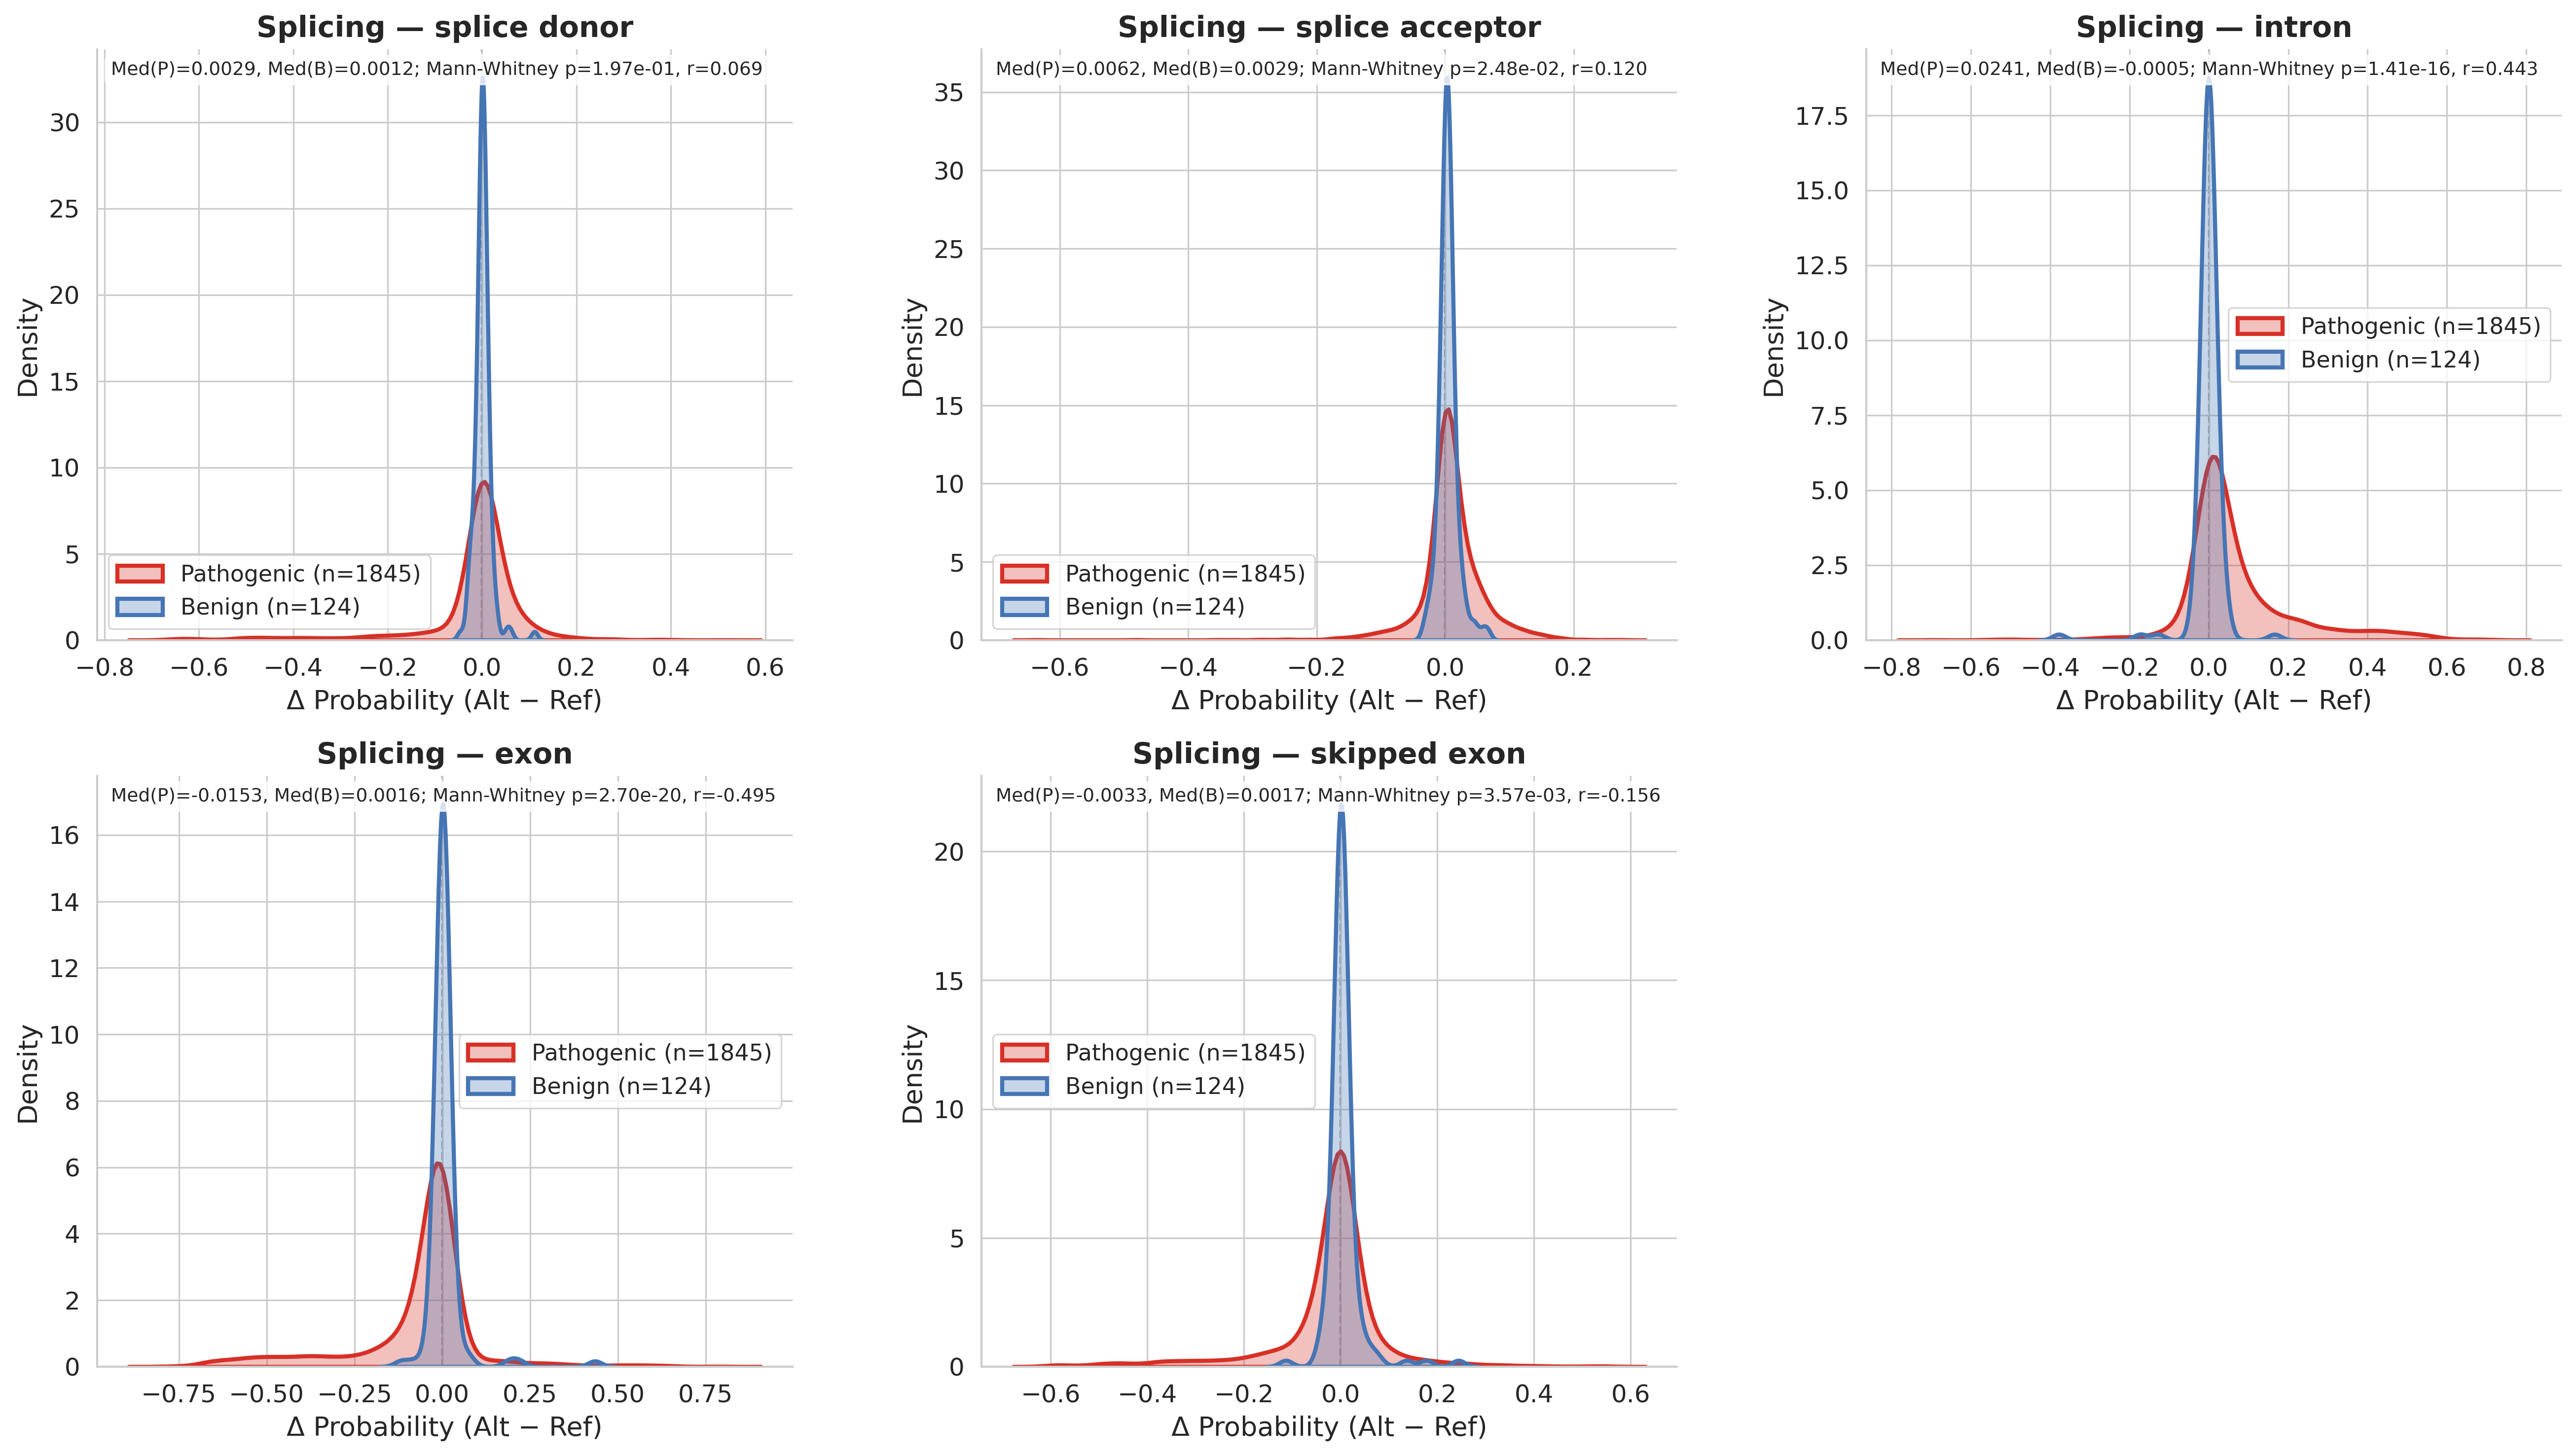

✅ Saved: kde_Truncation___Stop_bed_deltas.pdf


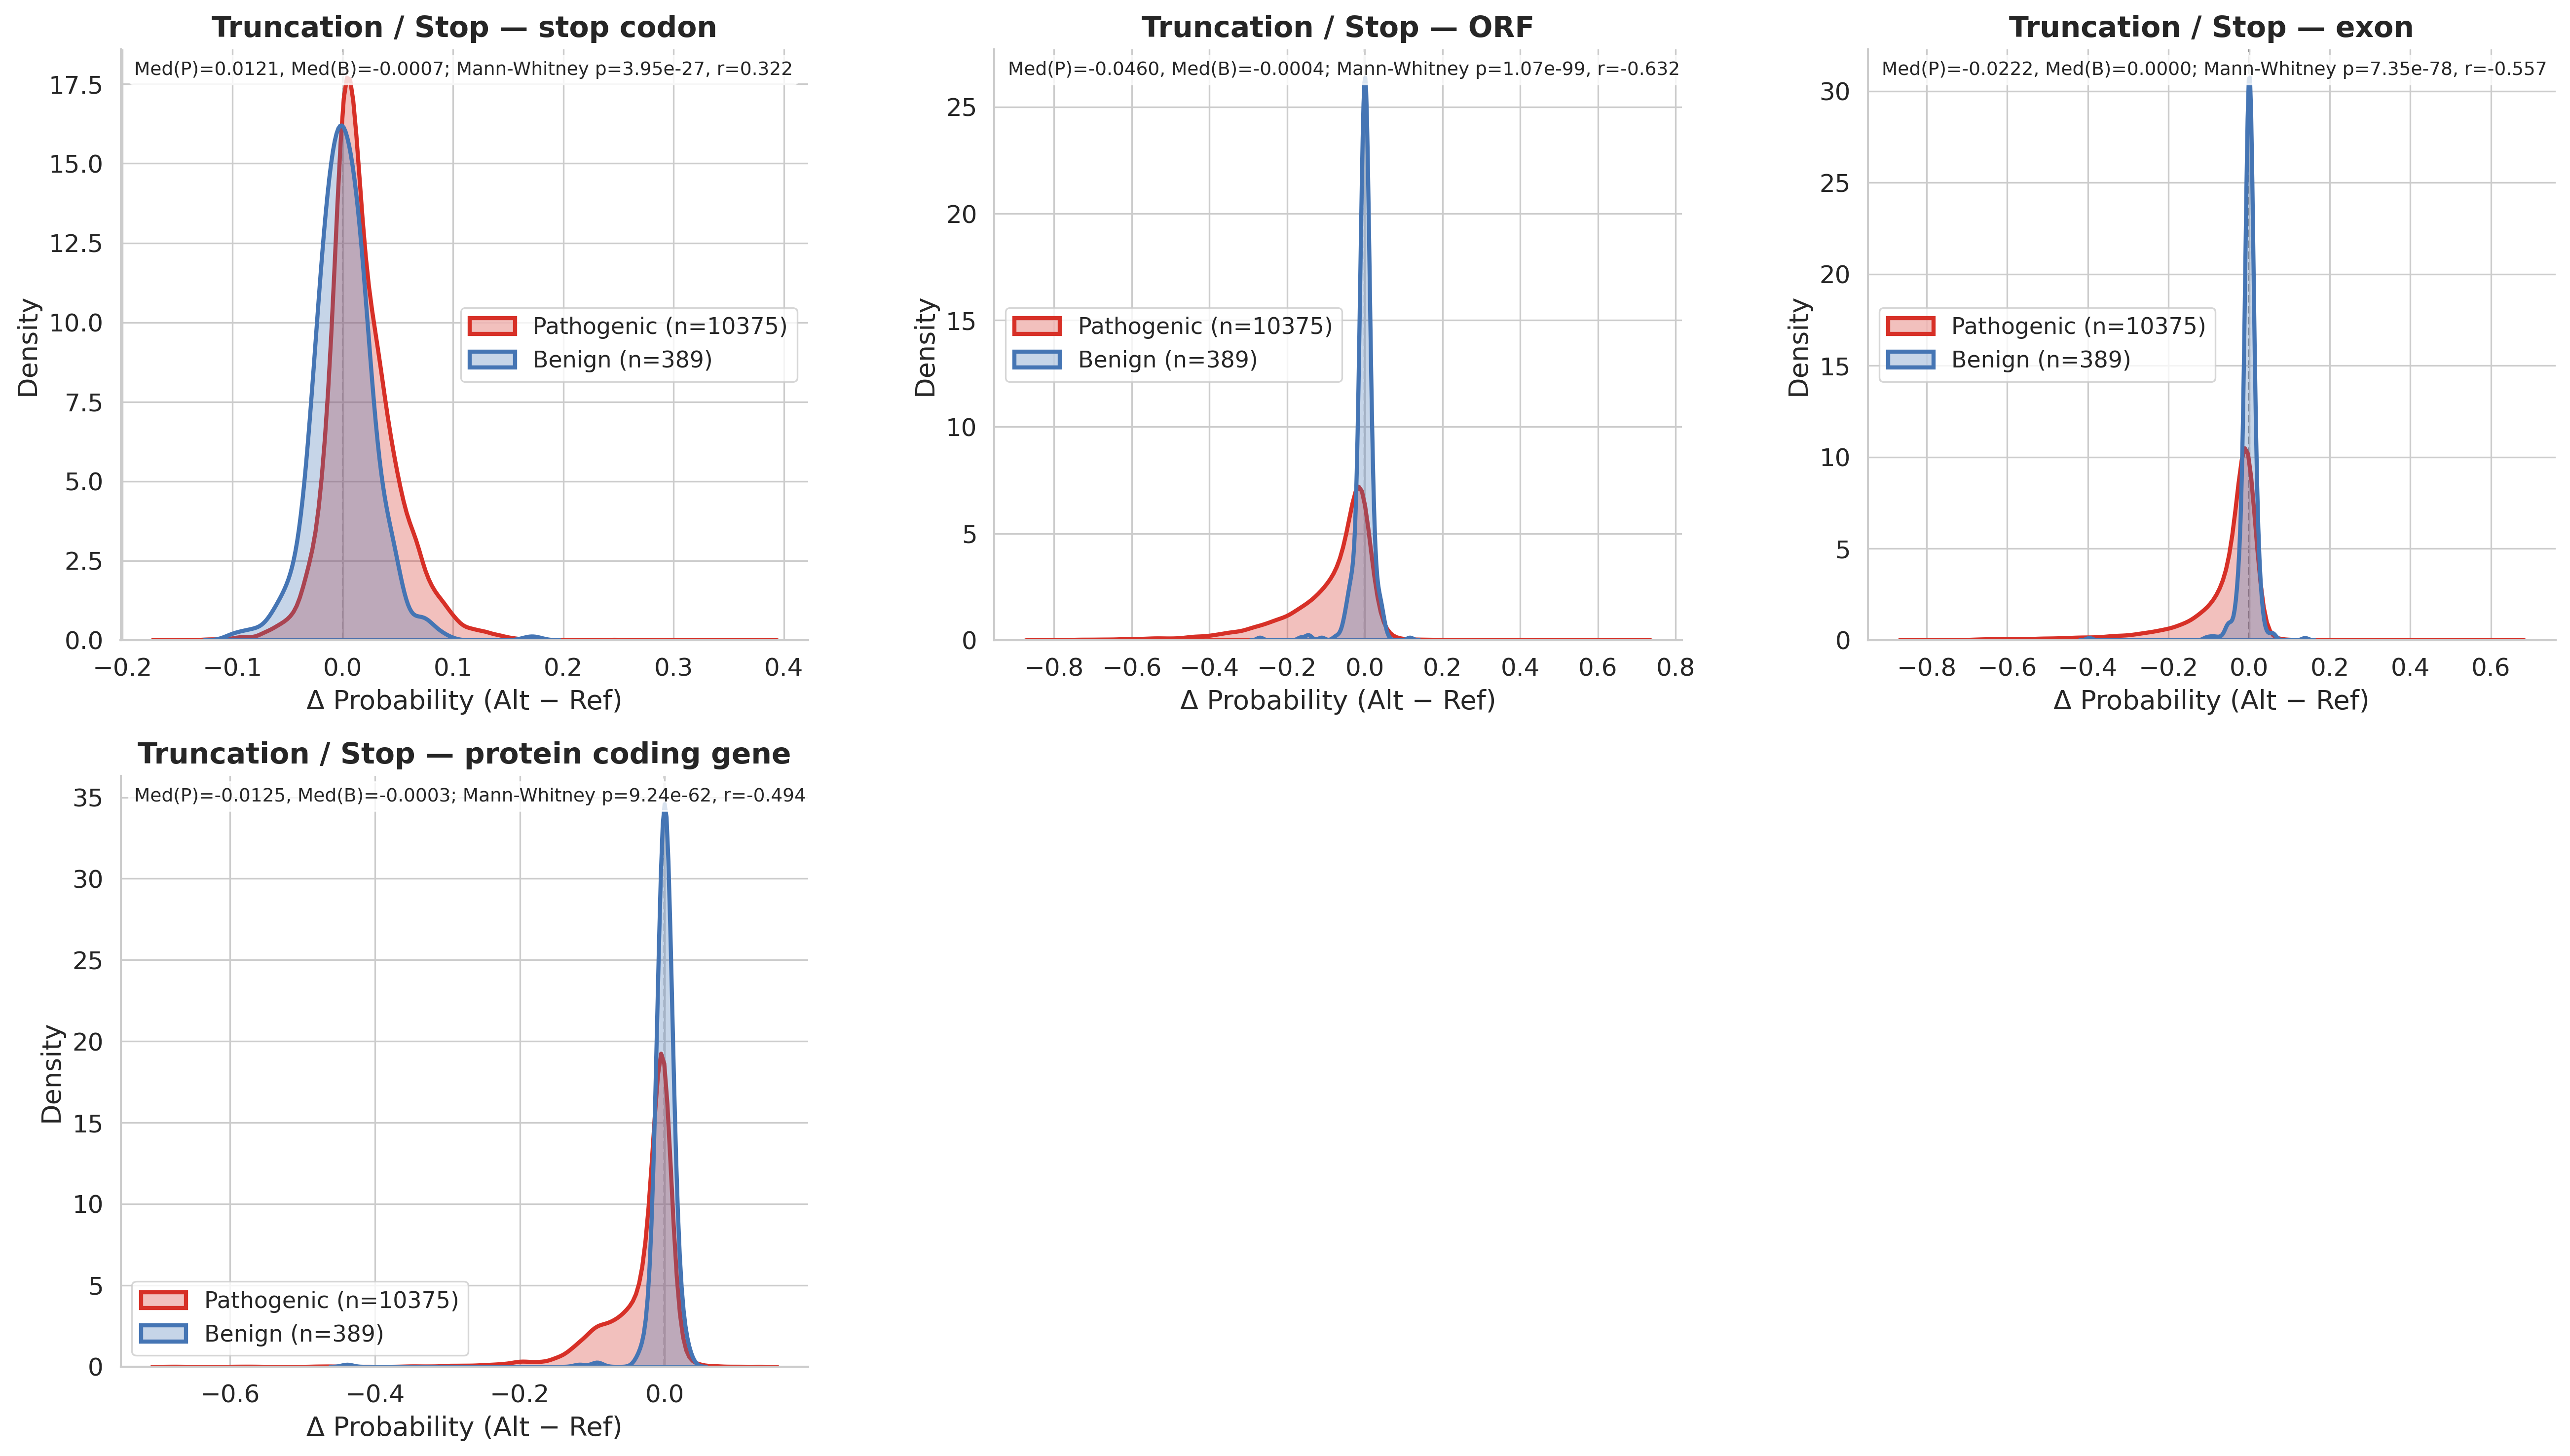

✅ Saved: kde_Start-loss___Initiation_bed_deltas.pdf


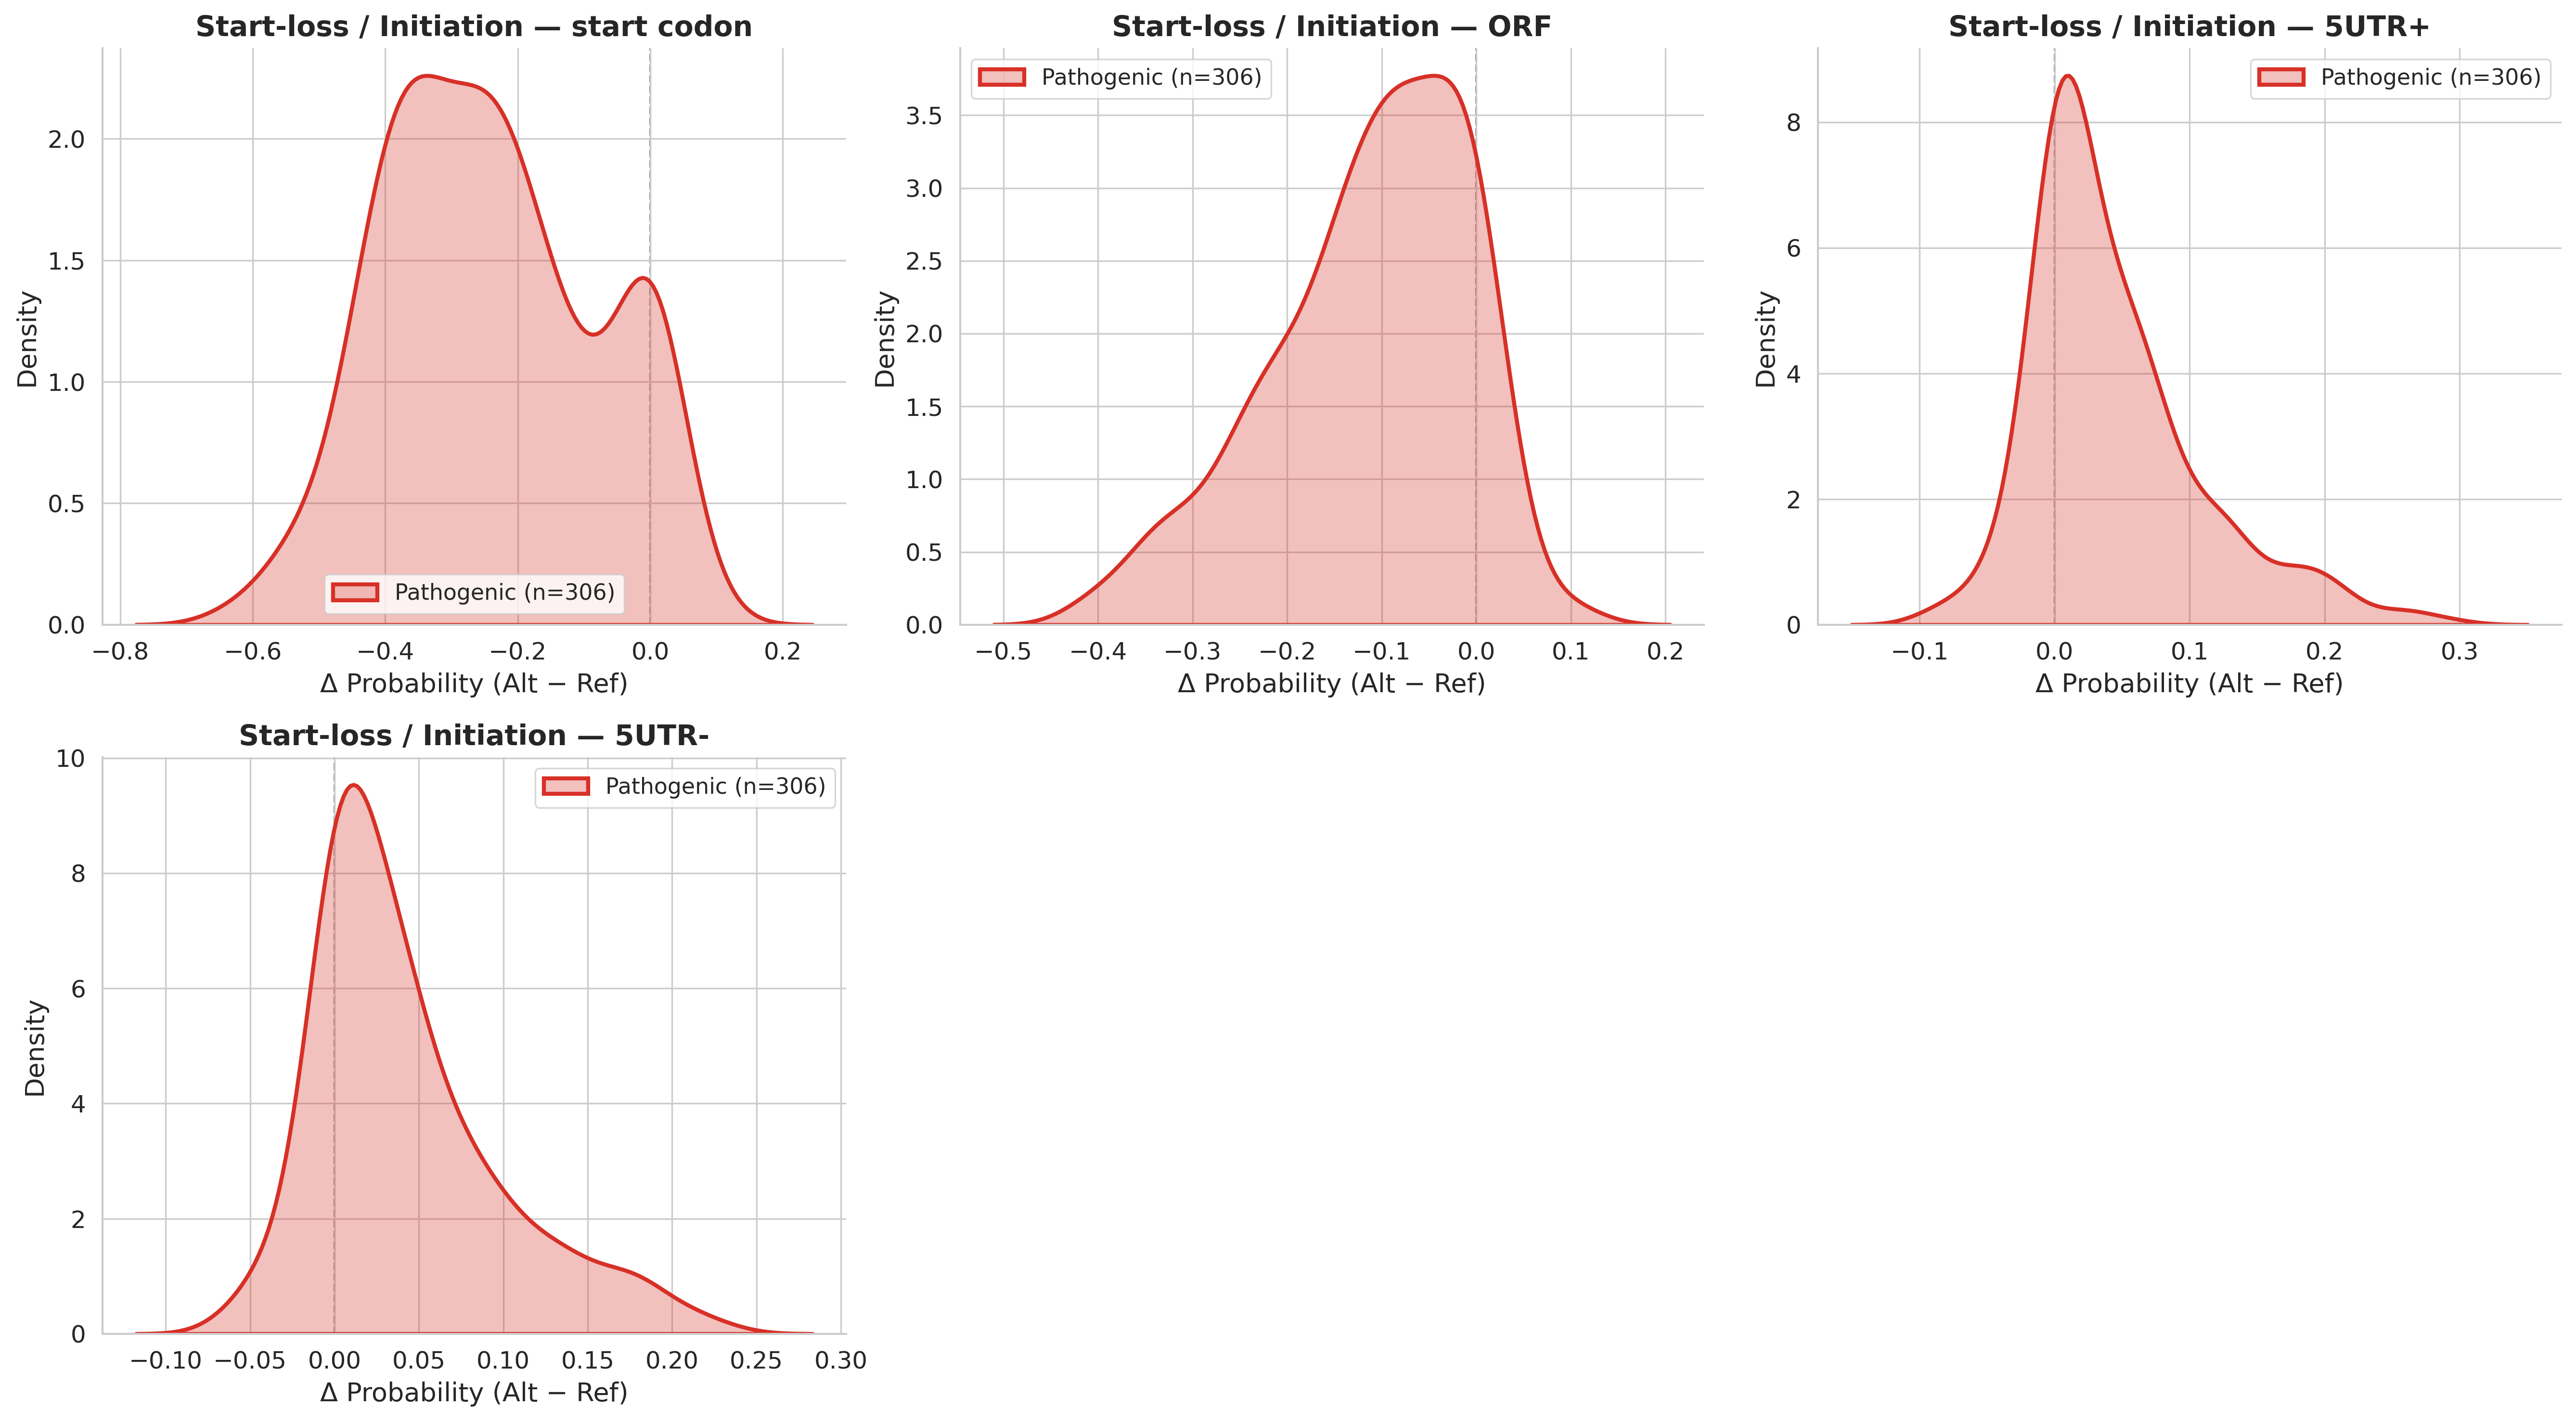

✅ Saved: kde_Missense___Protein_Function_bed_deltas.pdf


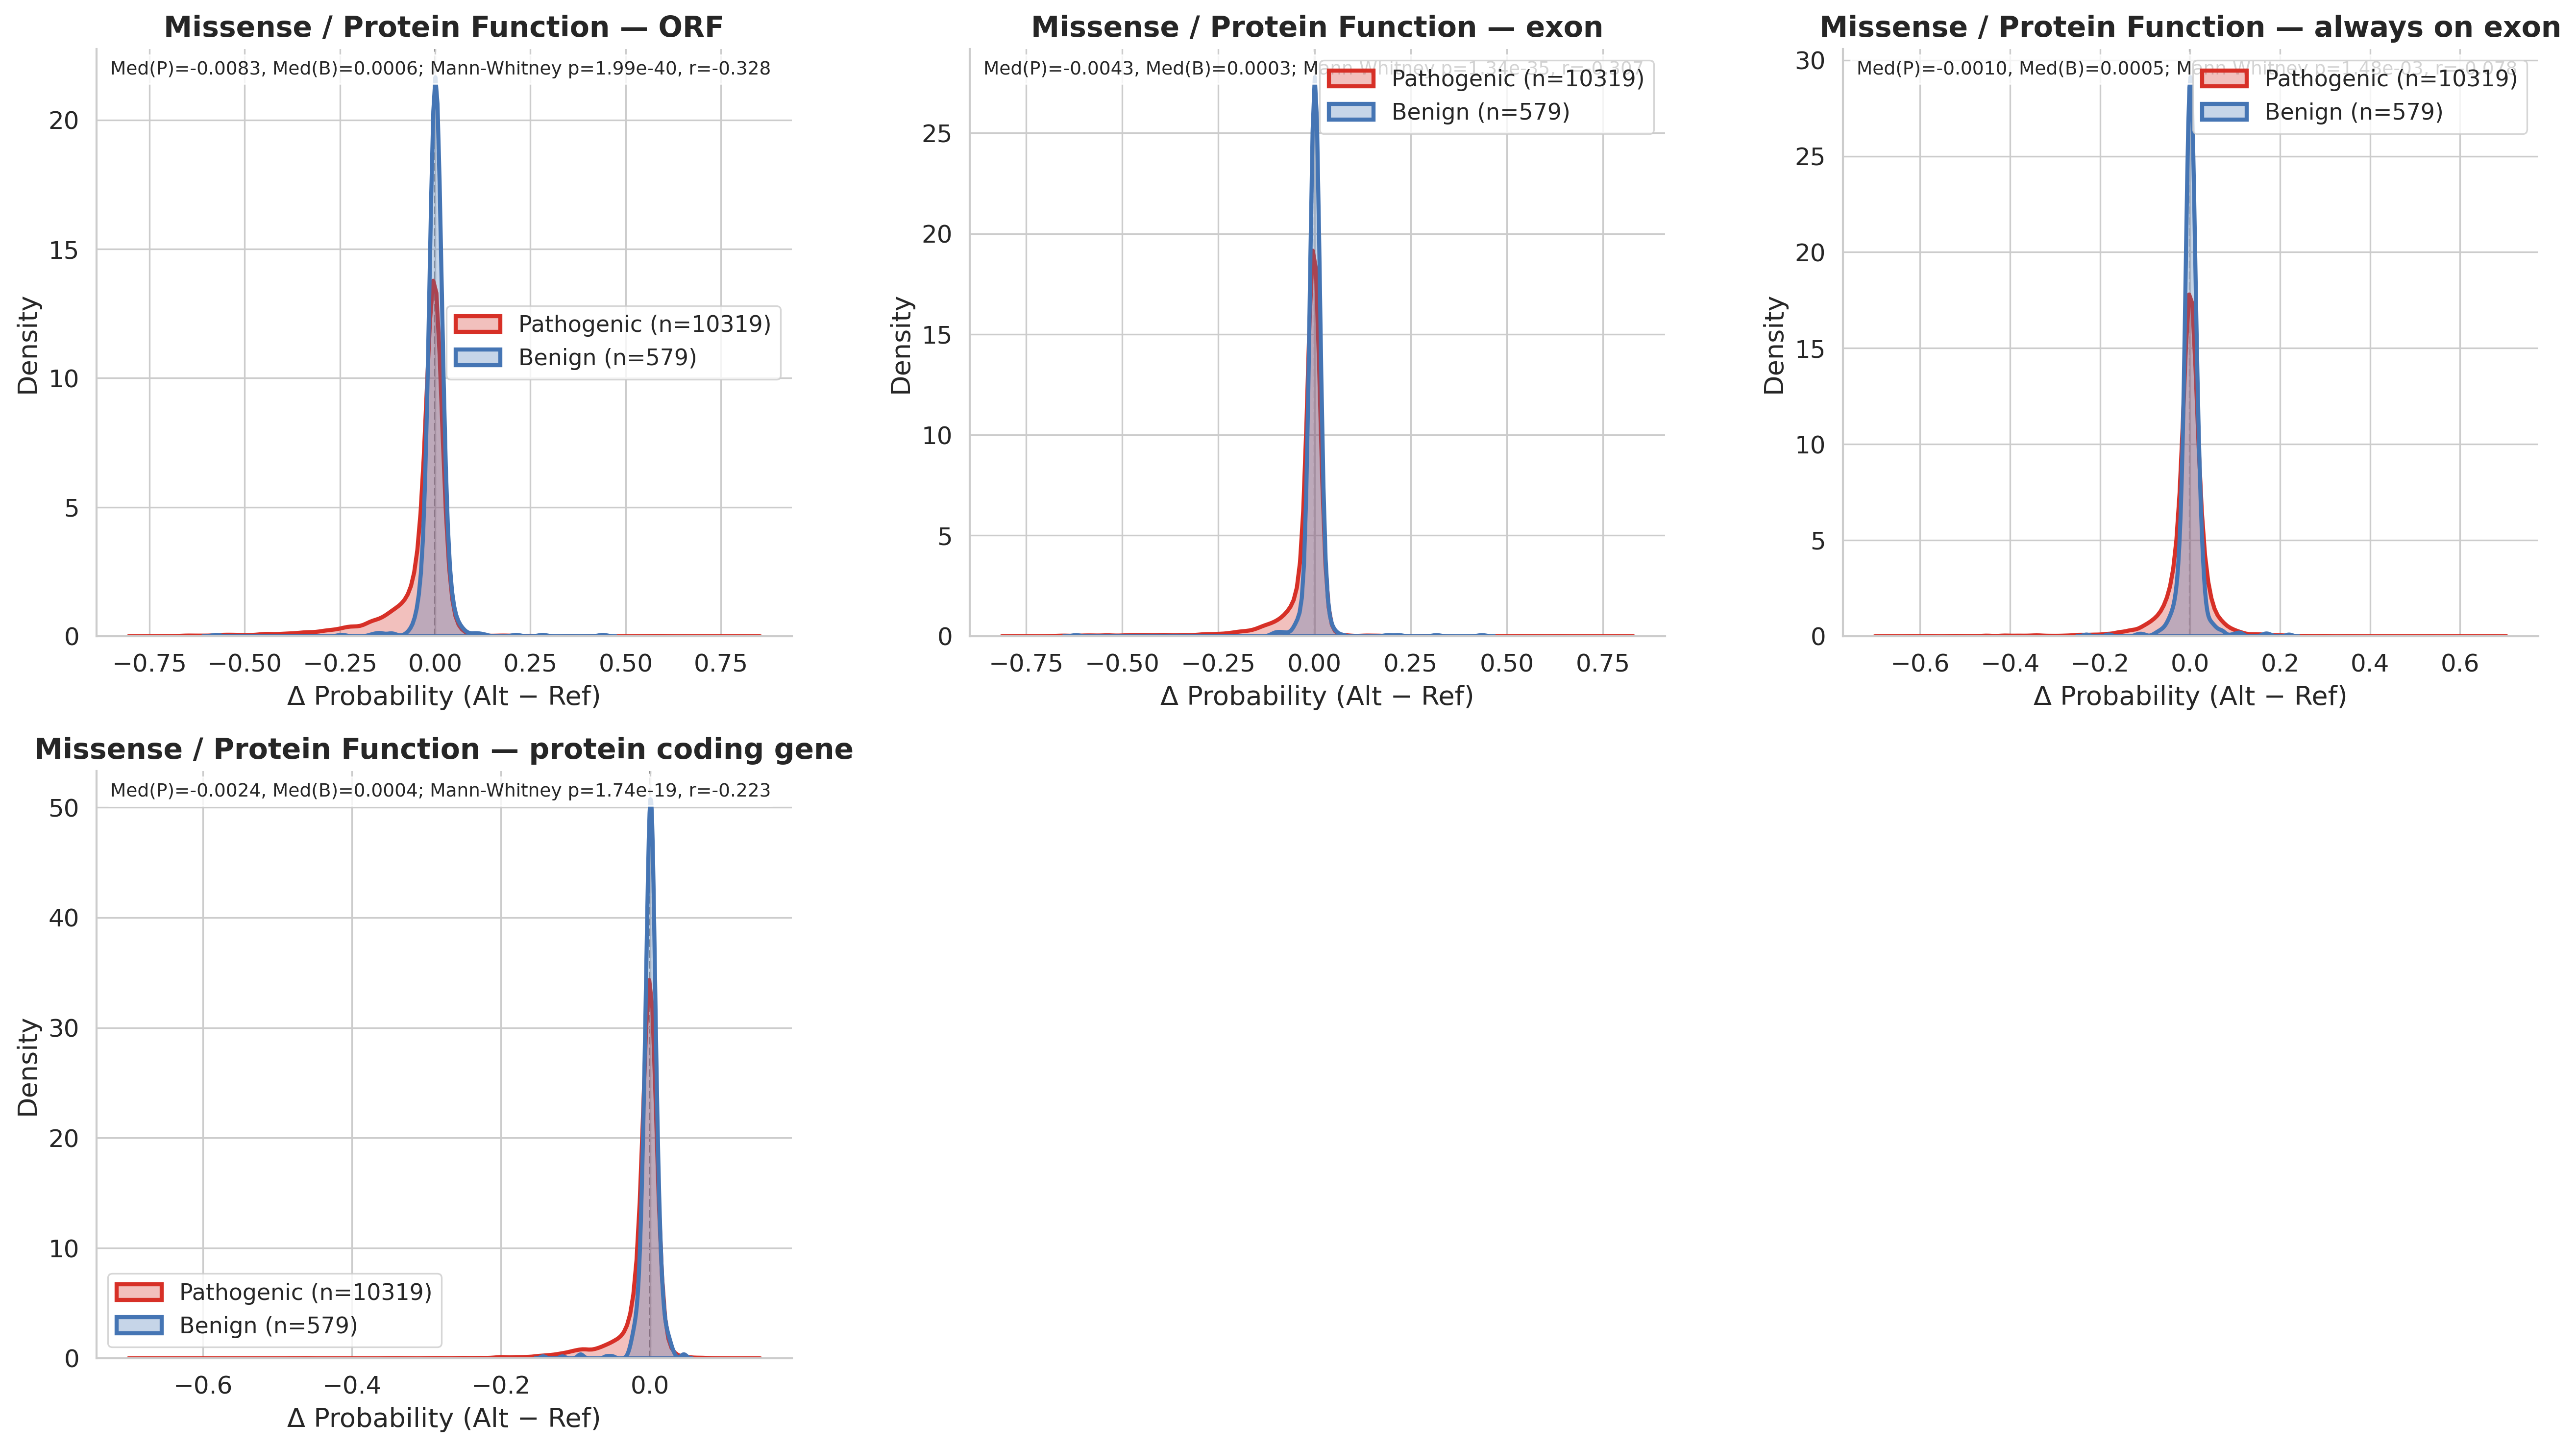

✅ Saved: kde_Frameshift_bed_deltas.pdf


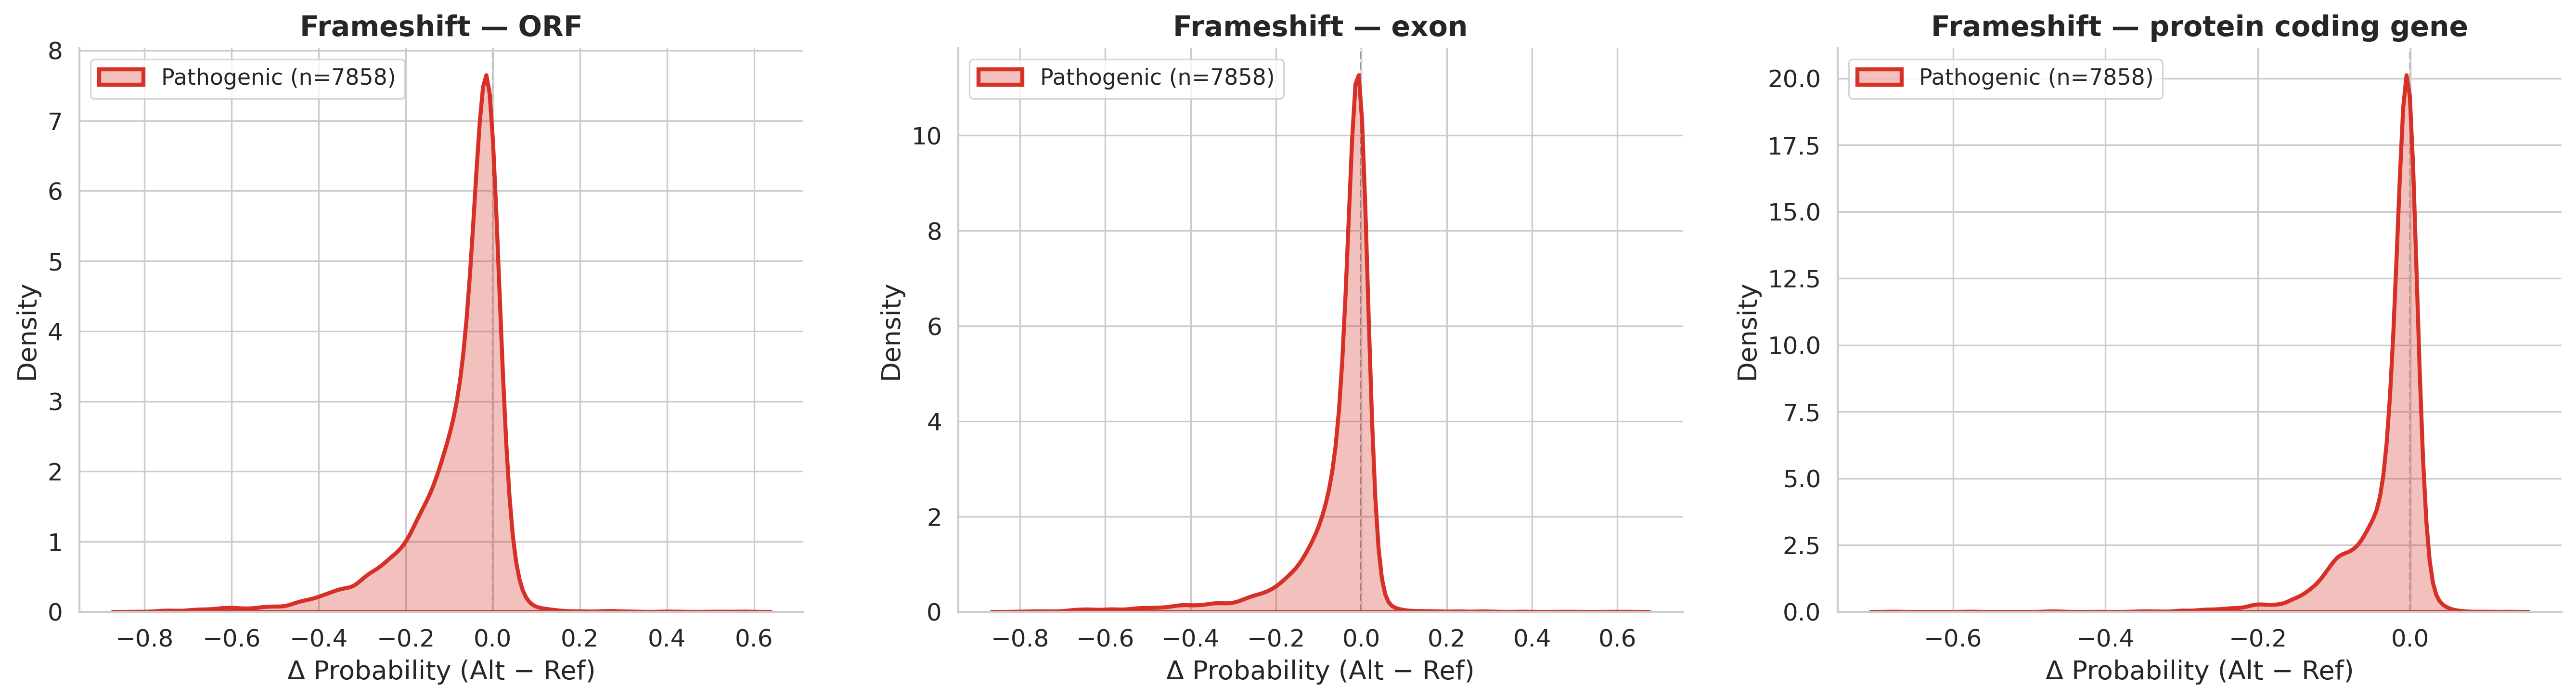

✅ Saved: kde_Regulatory___Promoter_bed_deltas.pdf


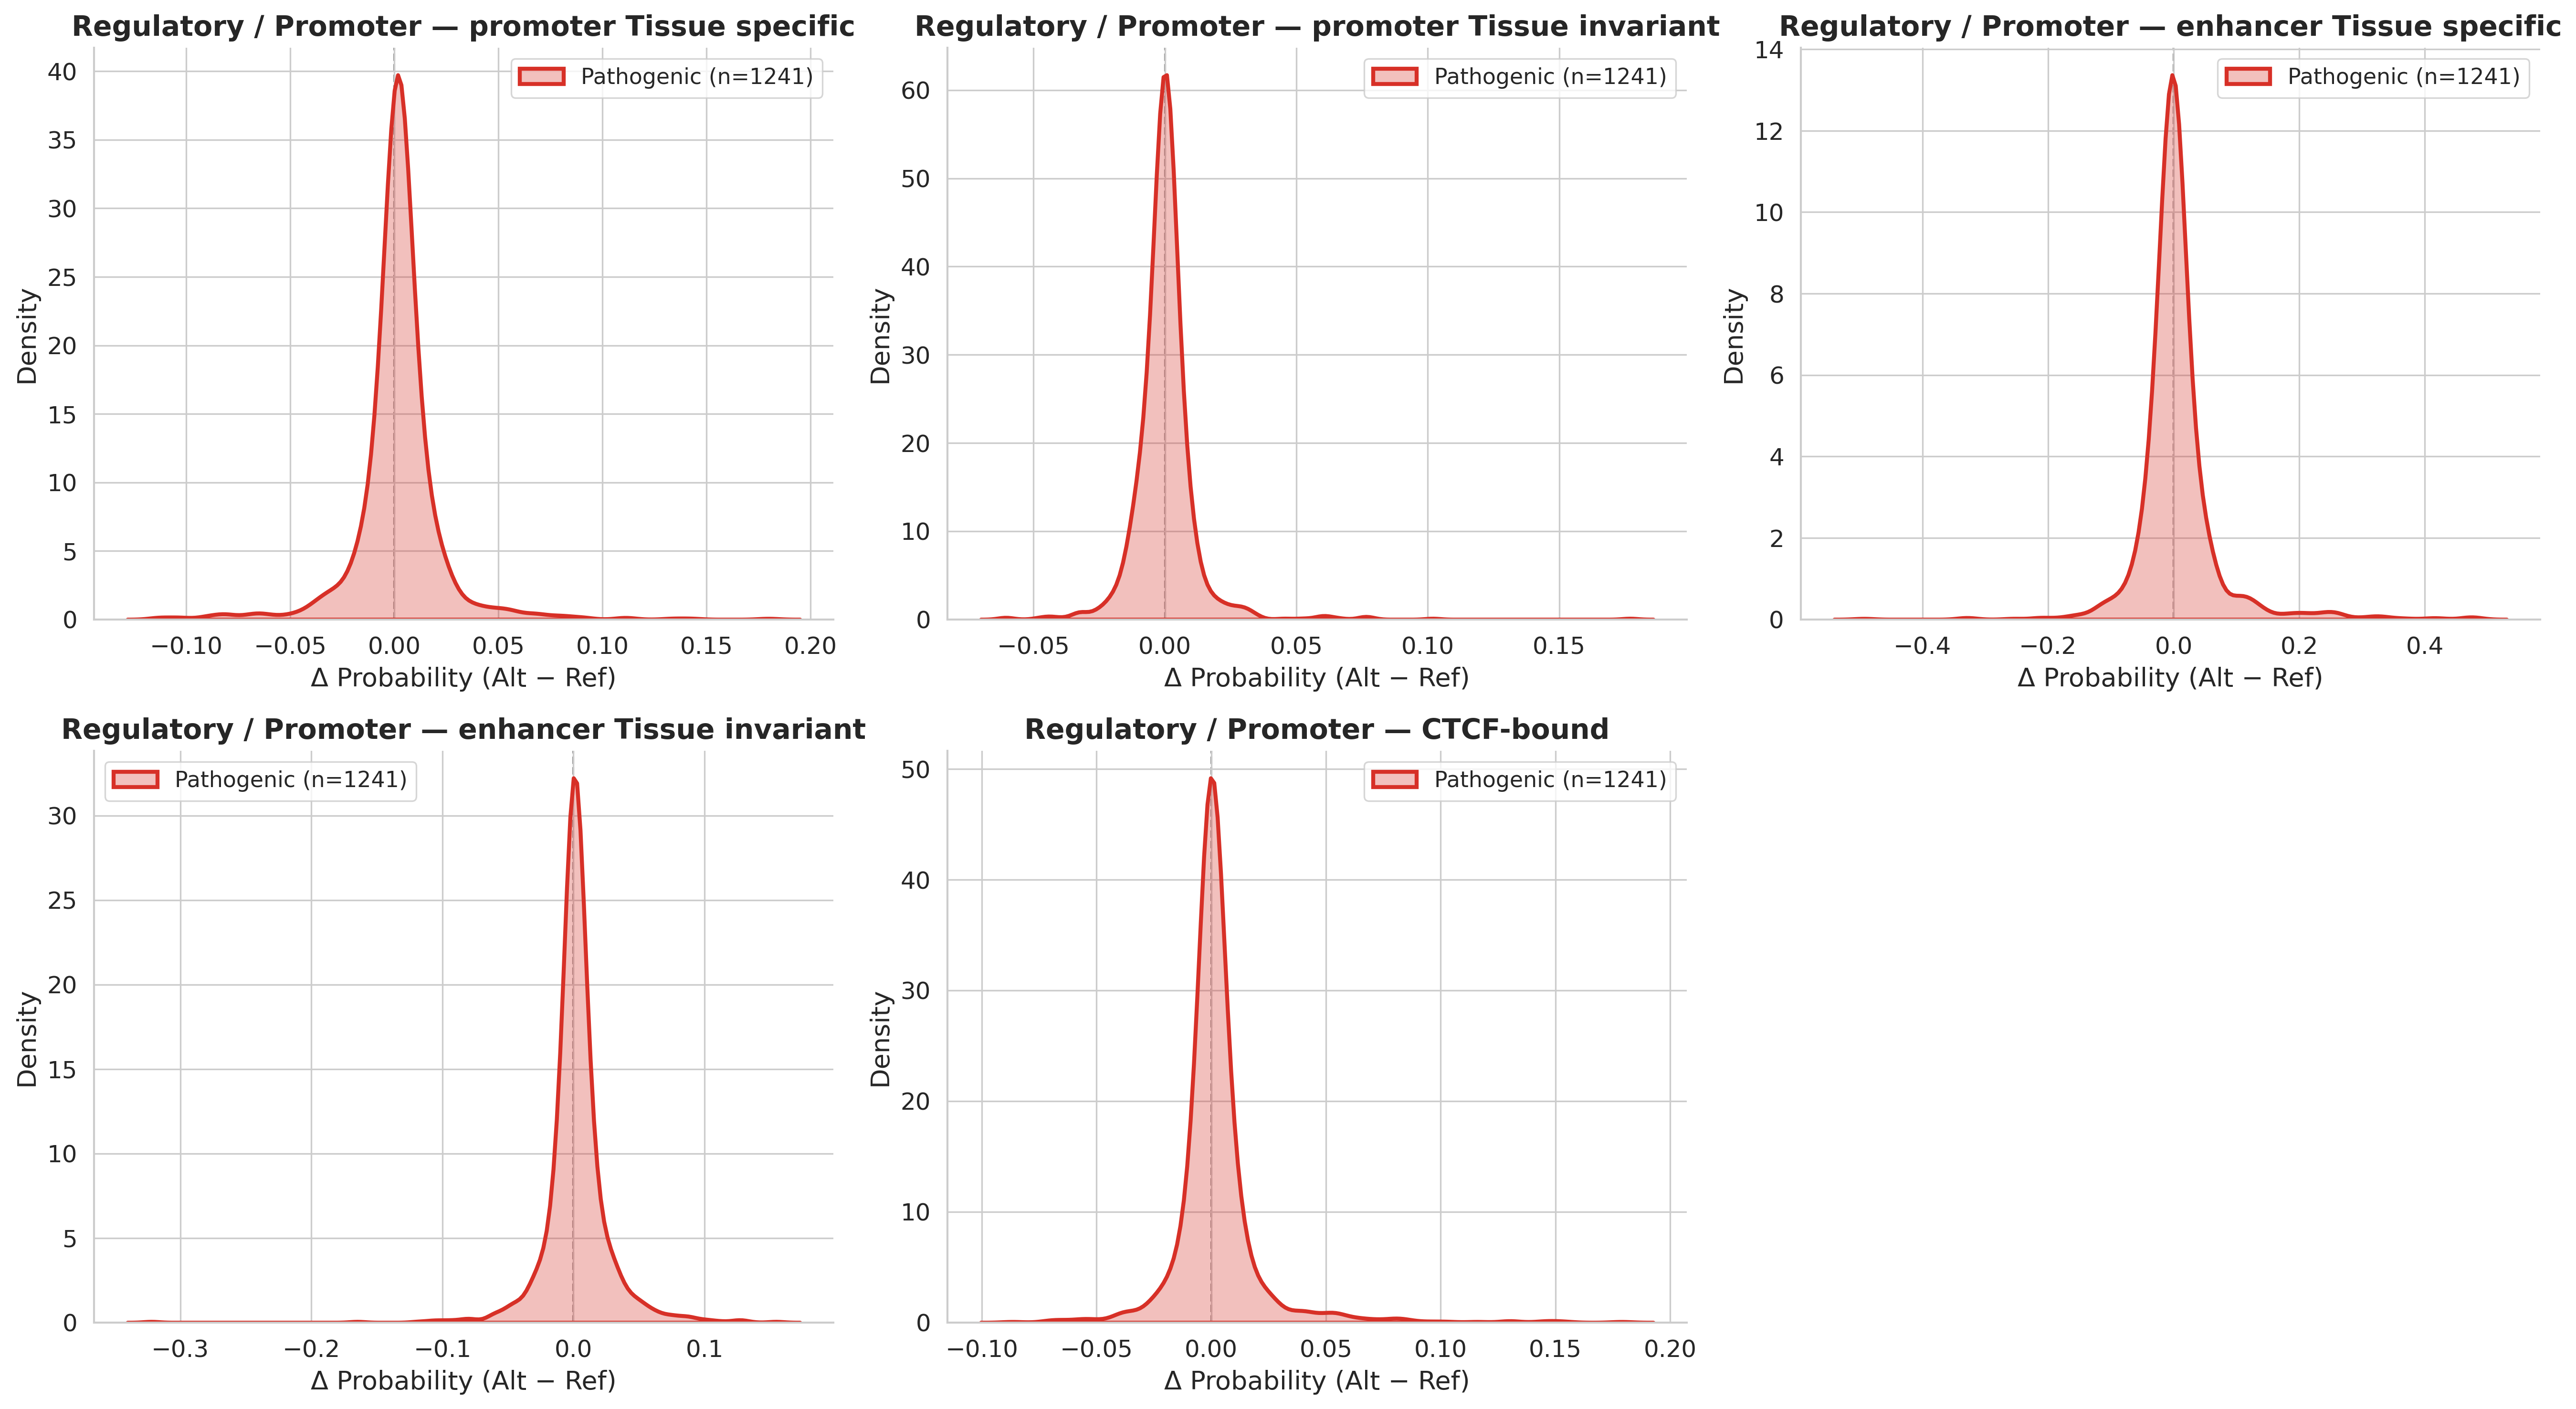

✅ Saved: kde_UTR___PolyA_bed_deltas.pdf


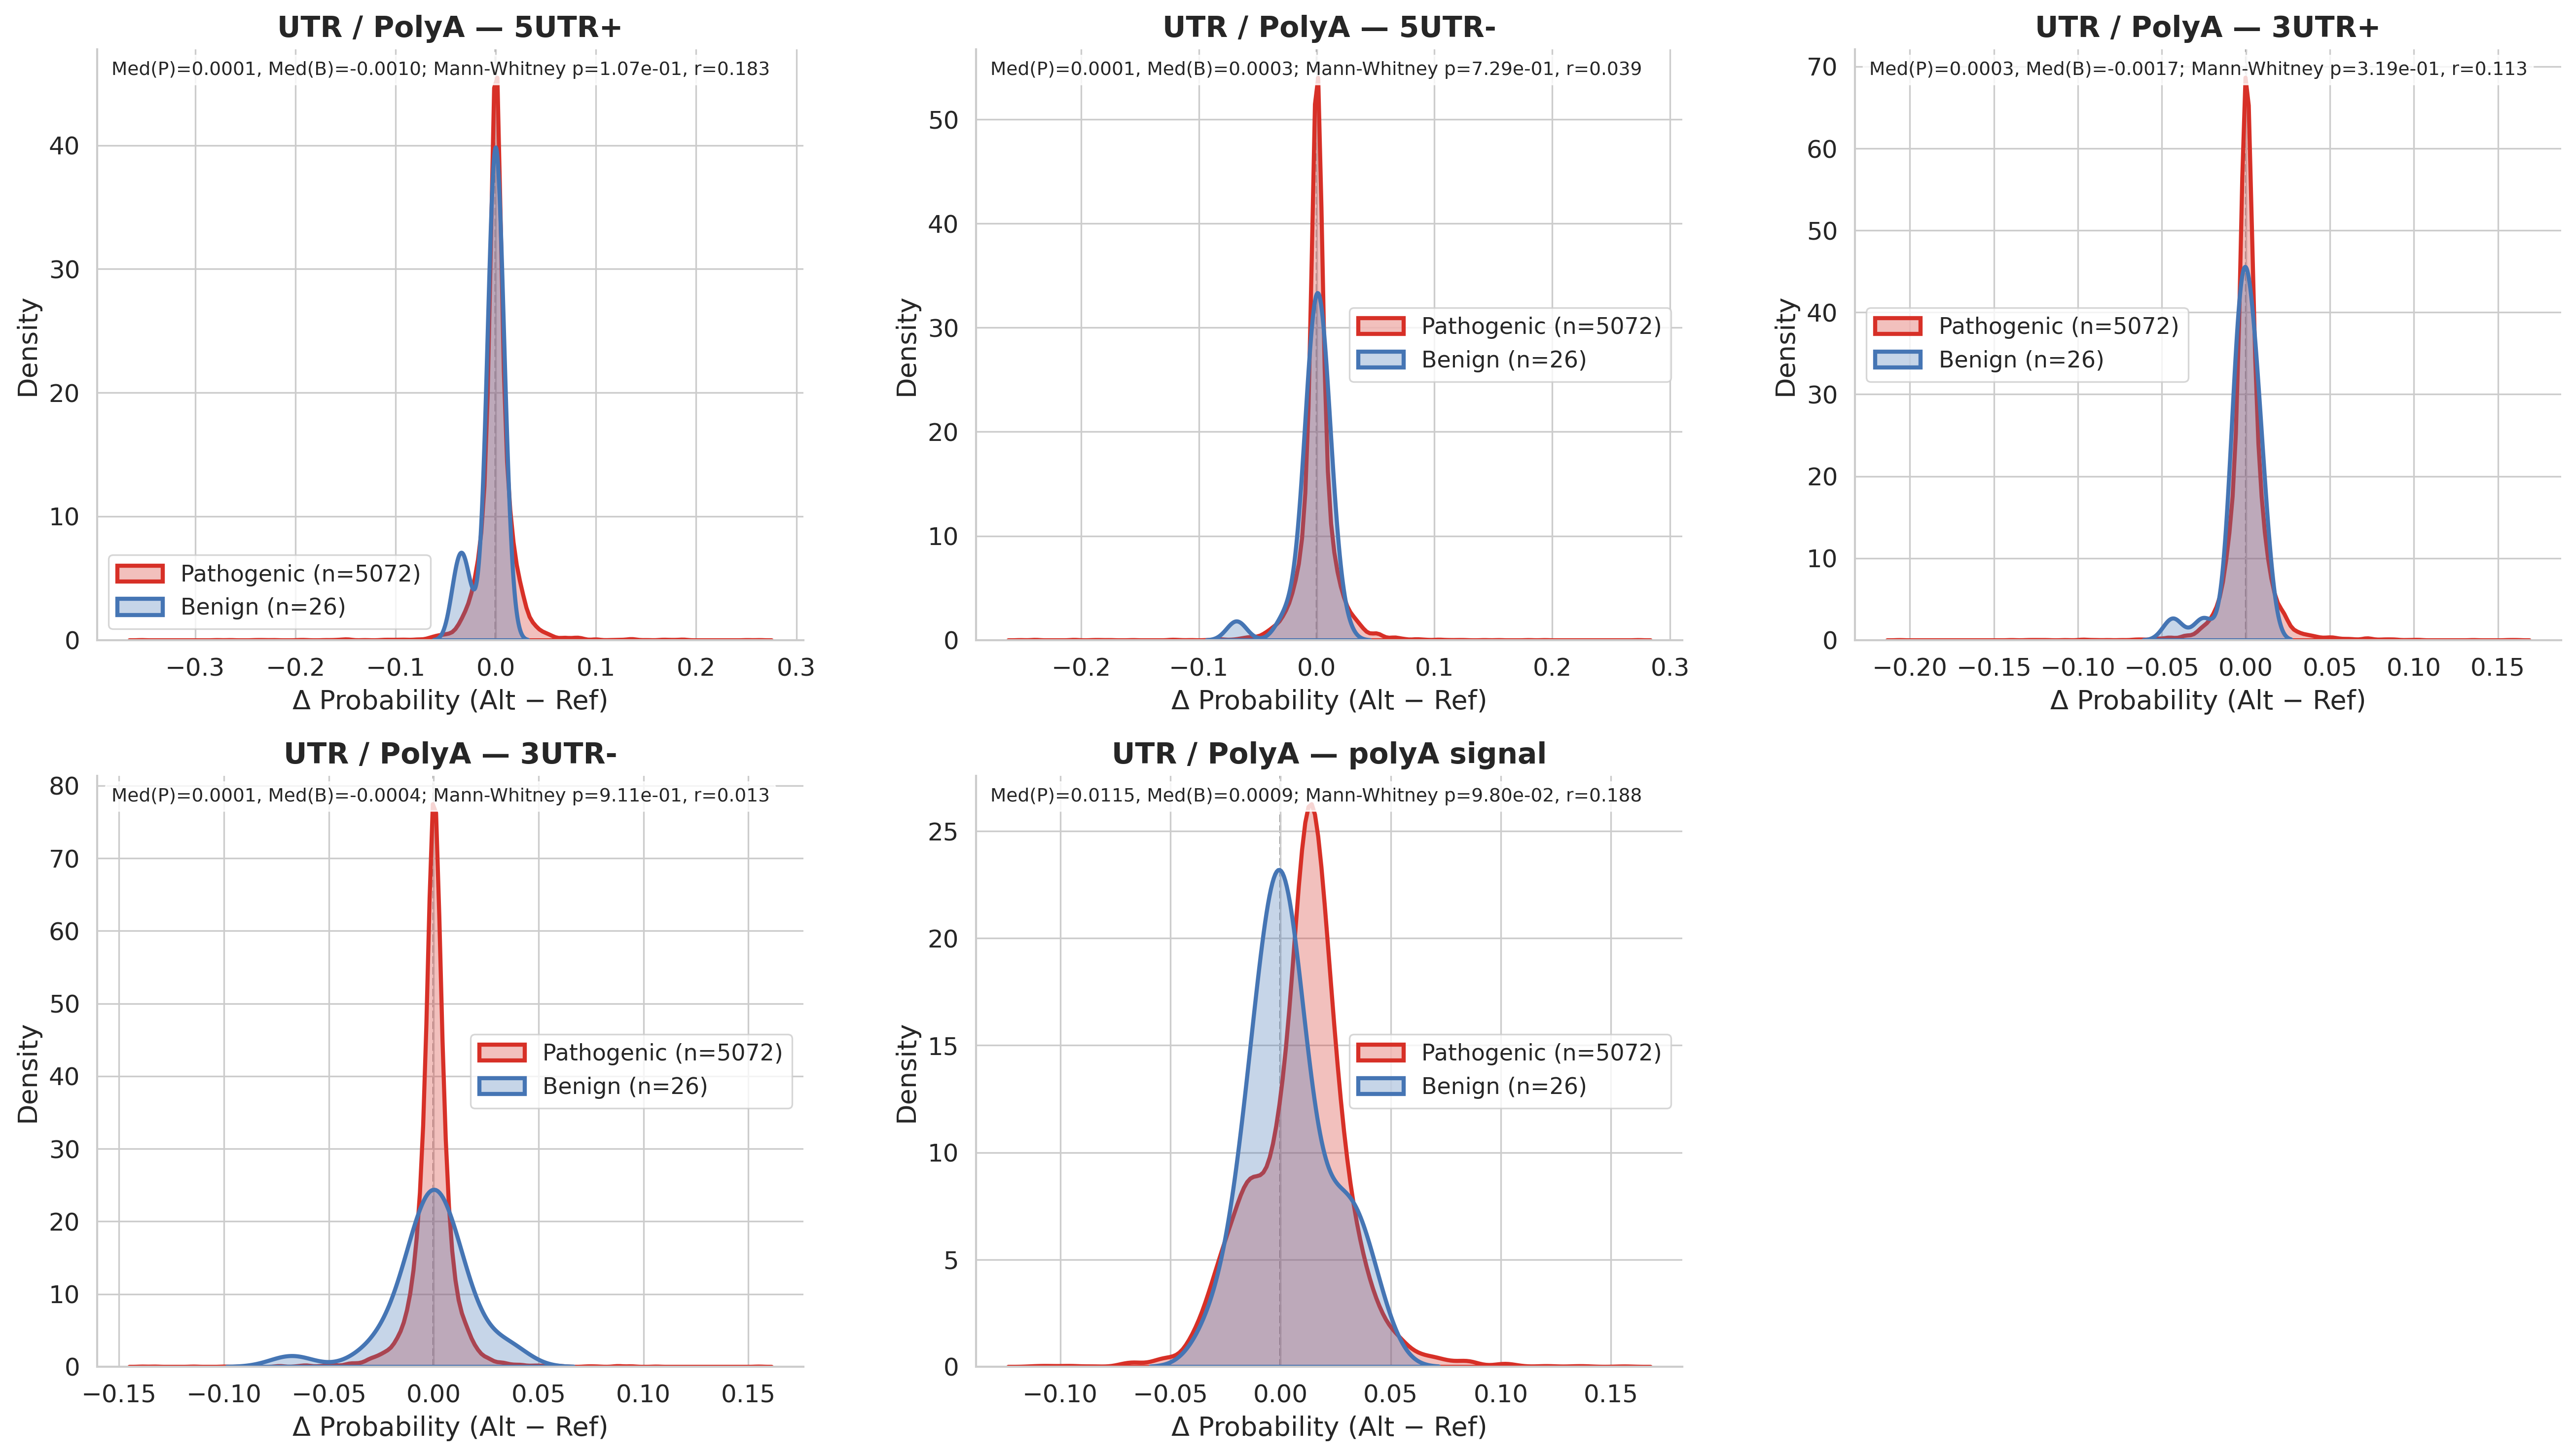

✅ KDE plots complete


In [8]:
# ============================================================================
# CREATE KDE PLOTS: BED DELTAS BY CONSEQUENCE GROUP
# ============================================================================
print("📊 Creating KDE plots for consequence groups × BED deltas...")

MIN_MATCHES_FOR_PLOT = 20
MIN_KDE_N = 10

# Filter to groups with sufficient matches
valid_groups = [
    (name, info)
    for name, info in CONSEQUENCE_GROUPS.items()
    if info.get("mask", pd.Series(False, index=df.index)).sum() >= MIN_MATCHES_FOR_PLOT
]

print(f"Plotting {len(valid_groups)} groups with >= {MIN_MATCHES_FOR_PLOT} matches")

for group_name, group_info in valid_groups:
    bed_cols = group_info["bed_cols"]

    if len(bed_cols) == 0:
        print(f"⚠️  Skipping {group_name}: no valid BED columns")
        continue

    # Determine grid layout
    n_cols = min(3, len(bed_cols))  # Max 3 columns
    n_rows = int(np.ceil(len(bed_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    # Flatten axes for easier indexing
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    # Plot each BED column
    for i, bed_col in enumerate(bed_cols):
        plot_consequence_bed_kde(
            df,
            group_name,
            group_info,
            bed_col,
            ax=axes[i],
            min_matches=MIN_MATCHES_FOR_PLOT,
            min_kde_n=MIN_KDE_N,
            add_stats=True,
        )

    # Hide unused subplots
    for j in range(len(bed_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    # Save figure
    safe_name = group_name.replace("/", "_").replace(" ", "_")
    fig_path = FIG_DIR / f"kde_{safe_name}_bed_deltas.pdf"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"✅ Saved: {fig_path.name}")

    plt.show()

print("✅ KDE plots complete")


📊 Computing effect sizes (median absolute delta) per consequence × BED element...

Effect size summary (top 10 by |difference|):

      Consequence         BED_Element  Med_|Δ|_Pathogenic  Med_|Δ|_Benign  Difference       P_value
Truncation / Stop                 ORF            0.049549        0.007959    0.041589 1.017778e-105
         Splicing              intron            0.039523        0.006064    0.033459  2.924865e-32
       Frameshift                 ORF            0.043536        0.014276    0.029259  1.086350e-01
         Splicing                exon            0.026669        0.006047    0.020622  8.782580e-19
Truncation / Stop                exon            0.024470        0.006177    0.018293  3.599089e-78
         Splicing        skipped exon            0.023345        0.005918    0.017426  3.109376e-20
         Splicing        splice donor            0.019604        0.006299    0.013305  4.174502e-20
       Frameshift                exon            0.021645        0.008

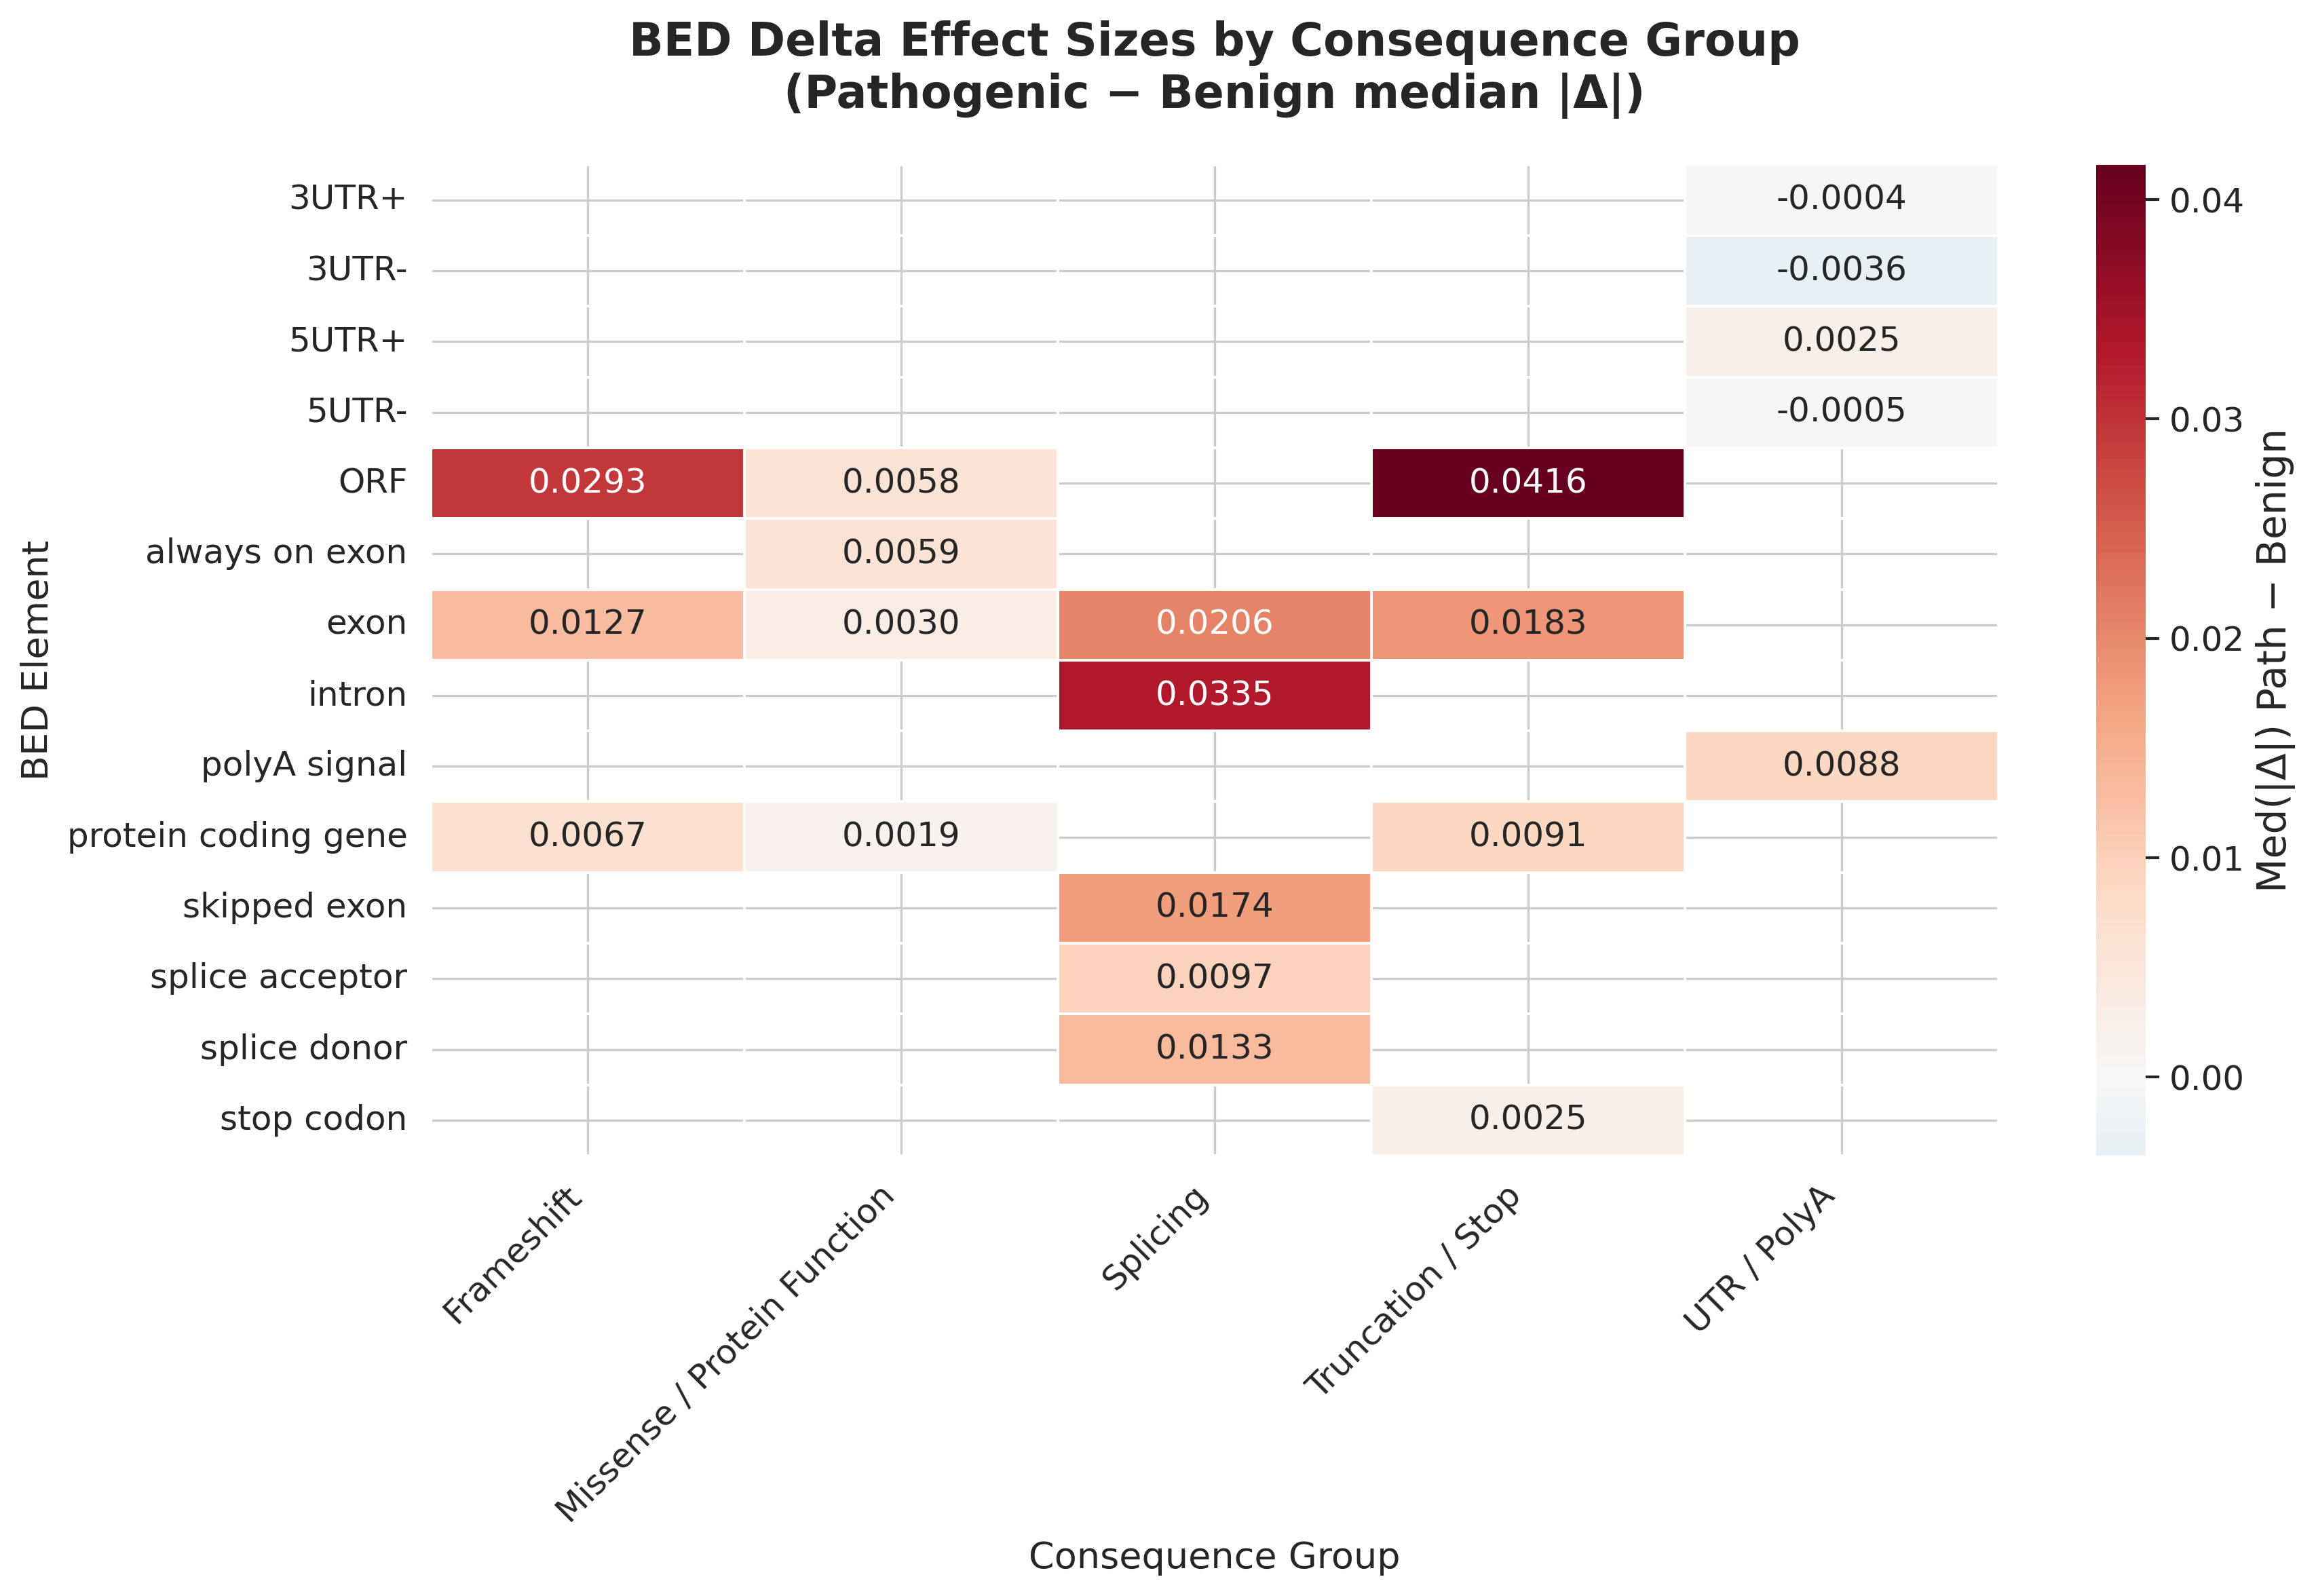

✅ Saved effect size table: effect_sizes_summary.csv


In [9]:
# ============================================================================
# SUMMARY FIGURE: EFFECT SIZES ACROSS CONSEQUENCE GROUPS
# ============================================================================
print(
    "📊 Computing effect sizes (median absolute delta) per consequence × BED element...\n"
)

# Collect effect size data
effect_size_data = []

for group_name, group_info in CONSEQUENCE_GROUPS.items():
    if "mask" not in group_info or group_info["mask"].sum() < MIN_MATCHES_FOR_PLOT:
        continue

    subset = df[group_info["mask"]].copy()

    for bed_col in group_info["bed_cols"]:
        # Separate by label
        path_vals = subset[subset["label"] == "Pathogenic"][bed_col].dropna()
        ben_vals = subset[subset["label"] == "Benign"][bed_col].dropna()

        if len(path_vals) < 5 or len(ben_vals) < 5:
            continue

        # Compute median absolute delta
        med_path = np.abs(path_vals).median()
        med_ben = np.abs(ben_vals).median()

        # Mann-Whitney U test
        stat, pval = stats.mannwhitneyu(
            np.abs(path_vals), np.abs(ben_vals), alternative="two-sided"
        )

        # Rank-biserial correlation (effect size)
        auc = stat / (len(path_vals) * len(ben_vals))
        effect = 2 * auc - 1

        bed_label = bed_col.replace("D_BED_", "").replace("_", " ")

        effect_size_data.append(
            {
                "Consequence": group_name,
                "BED_Element": bed_label,
                "Med_|Δ|_Pathogenic": med_path,
                "Med_|Δ|_Benign": med_ben,
                "Difference": med_path - med_ben,
                "P_value": pval,
                "Effect_Size_r": effect,
                "N_Pathogenic": len(path_vals),
                "N_Benign": len(ben_vals),
            }
        )

effect_df = pd.DataFrame(effect_size_data)

if len(effect_df) > 0:
    # Sort by difference
    effect_df = effect_df.sort_values("Difference", ascending=False)

    print(f"Effect size summary (top 10 by |difference|):\n")
    print(
        effect_df.head(10)[
            [
                "Consequence",
                "BED_Element",
                "Med_|Δ|_Pathogenic",
                "Med_|Δ|_Benign",
                "Difference",
                "P_value",
            ]
        ].to_string(index=False)
    )

    # Create heatmap pivot
    pivot = effect_df.pivot_table(
        index="BED_Element", columns="Consequence", values="Difference", aggfunc="first"
    )

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".4f",
        cmap="RdBu_r",
        center=0,
        cbar_kws={"label": "Med(|Δ|) Path − Benign"},
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title(
        "BED Delta Effect Sizes by Consequence Group\n(Pathogenic − Benign median |Δ|)",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    ax.set_xlabel("Consequence Group", fontsize=13)
    ax.set_ylabel("BED Element", fontsize=13)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save
    fig_path = FIG_DIR / "heatmap_effect_sizes_consequence_bed.pdf"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"\n✅ Saved: {fig_path.name}")
    plt.show()

    # Save effect size table
    table_path = FIG_DIR / "effect_sizes_summary.csv"
    effect_df.to_csv(table_path, index=False)
    print(f"✅ Saved effect size table: {table_path.name}")
else:
    print("⚠️  No effect size data computed (insufficient matches)")

🧬 Analyzing BED deltas by region_class (structural annotation)...
Region class distribution:
region_class
CODING         21151
INTRONIC         653
SPLICE           152
UTR_3             58
PROMOTER          25
UTR_5             21
OTHER             18
GENIC_OTHER        9
Name: count, dtype: int64
Plotting 5 region classes with >= 20 variants
✅ Saved: kde_region_CODING_bed_deltas.pdf


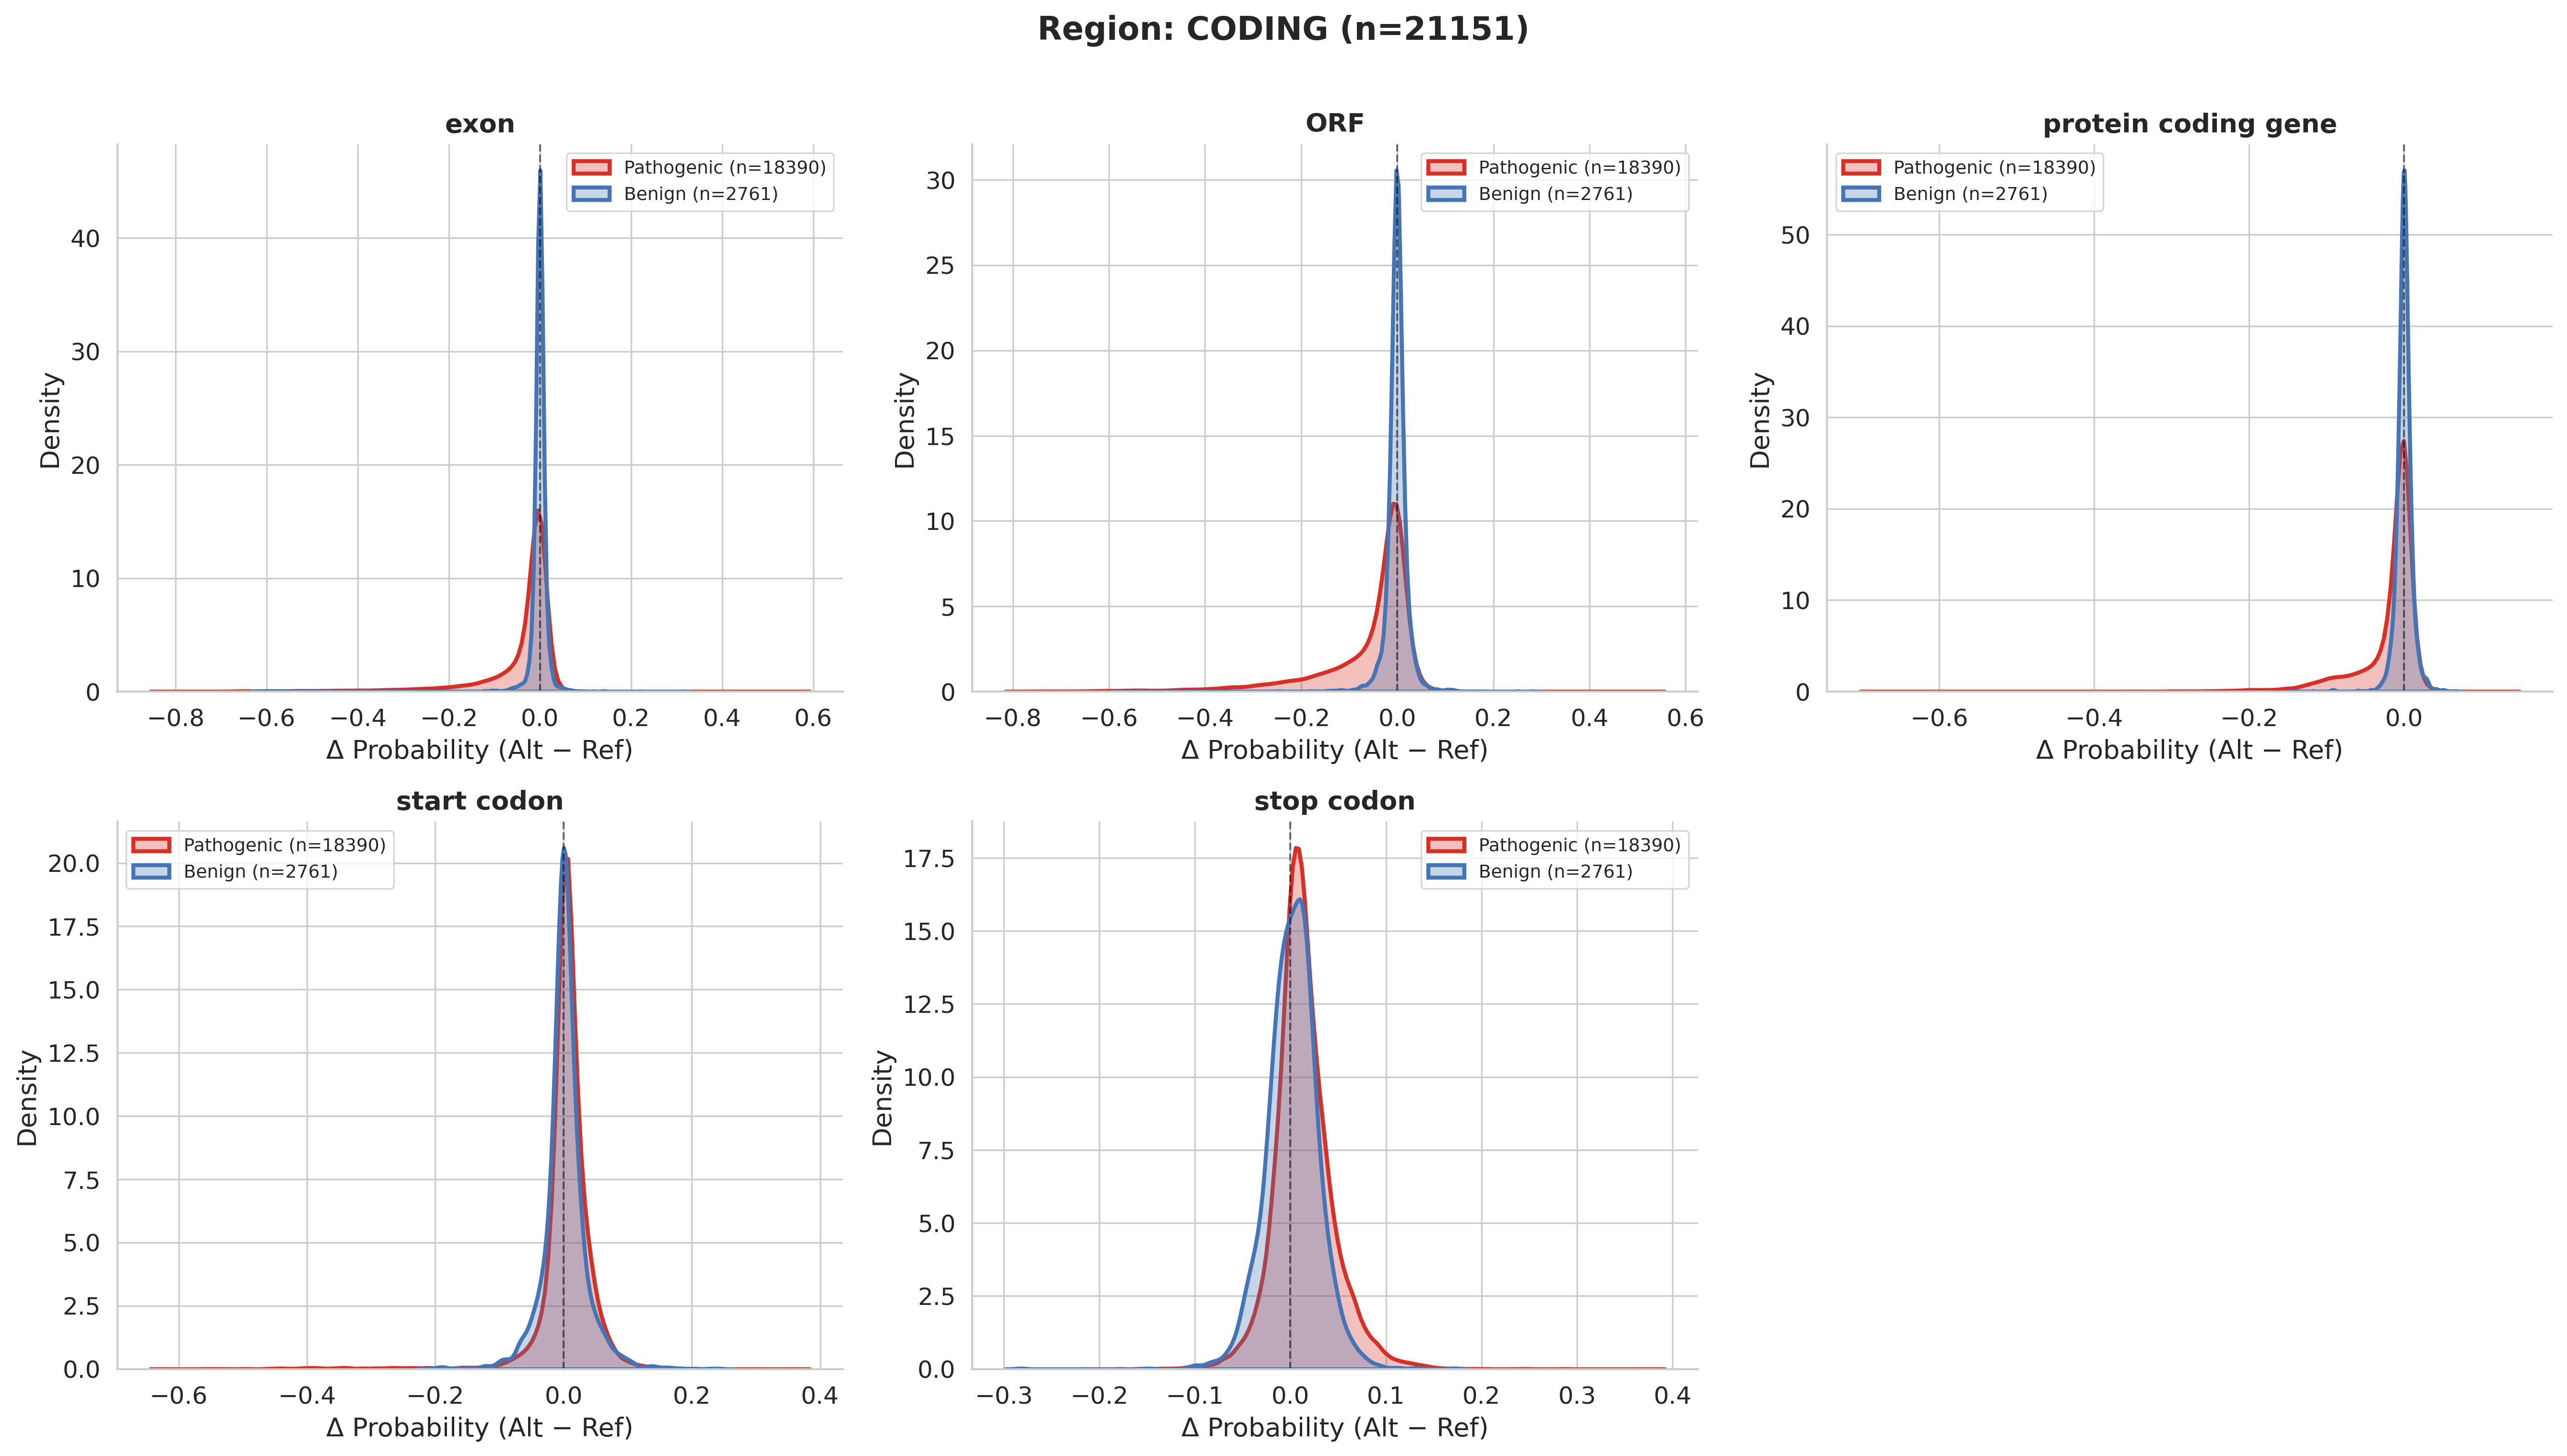

✅ Saved: kde_region_SPLICE_bed_deltas.pdf


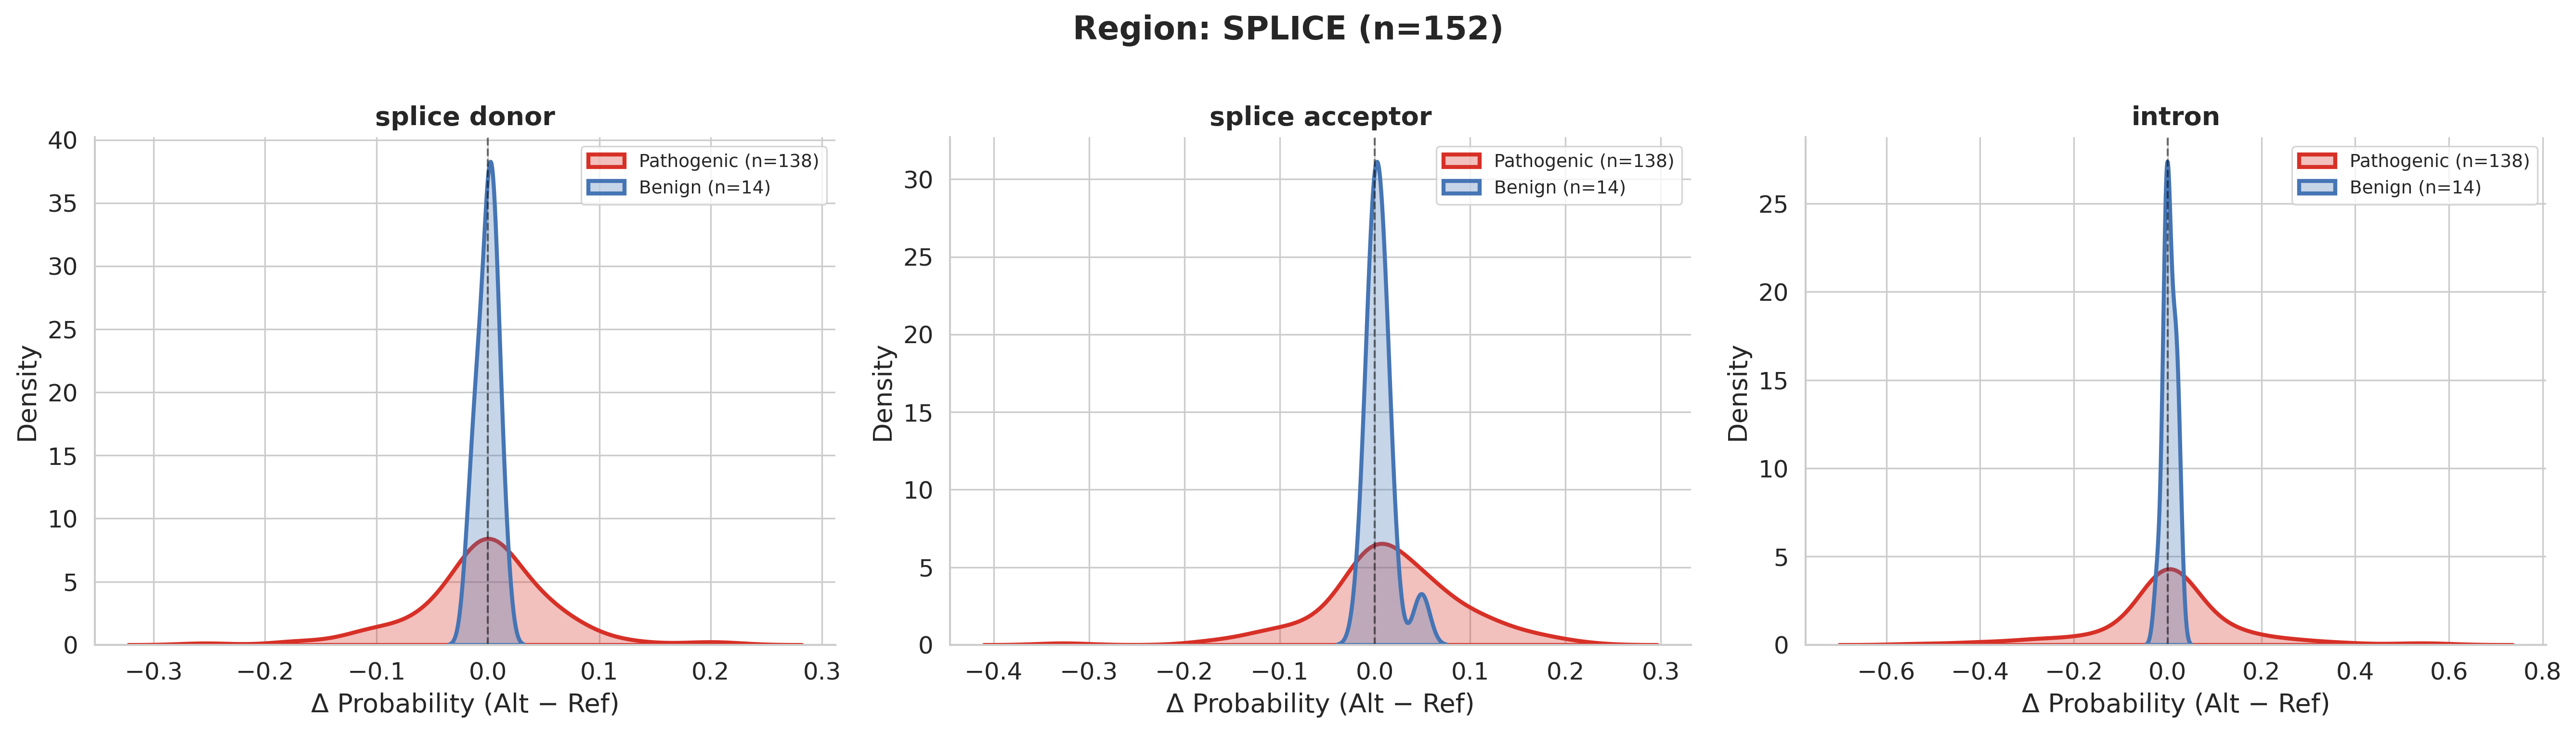

✅ Saved: kde_region_UTR_5_bed_deltas.pdf


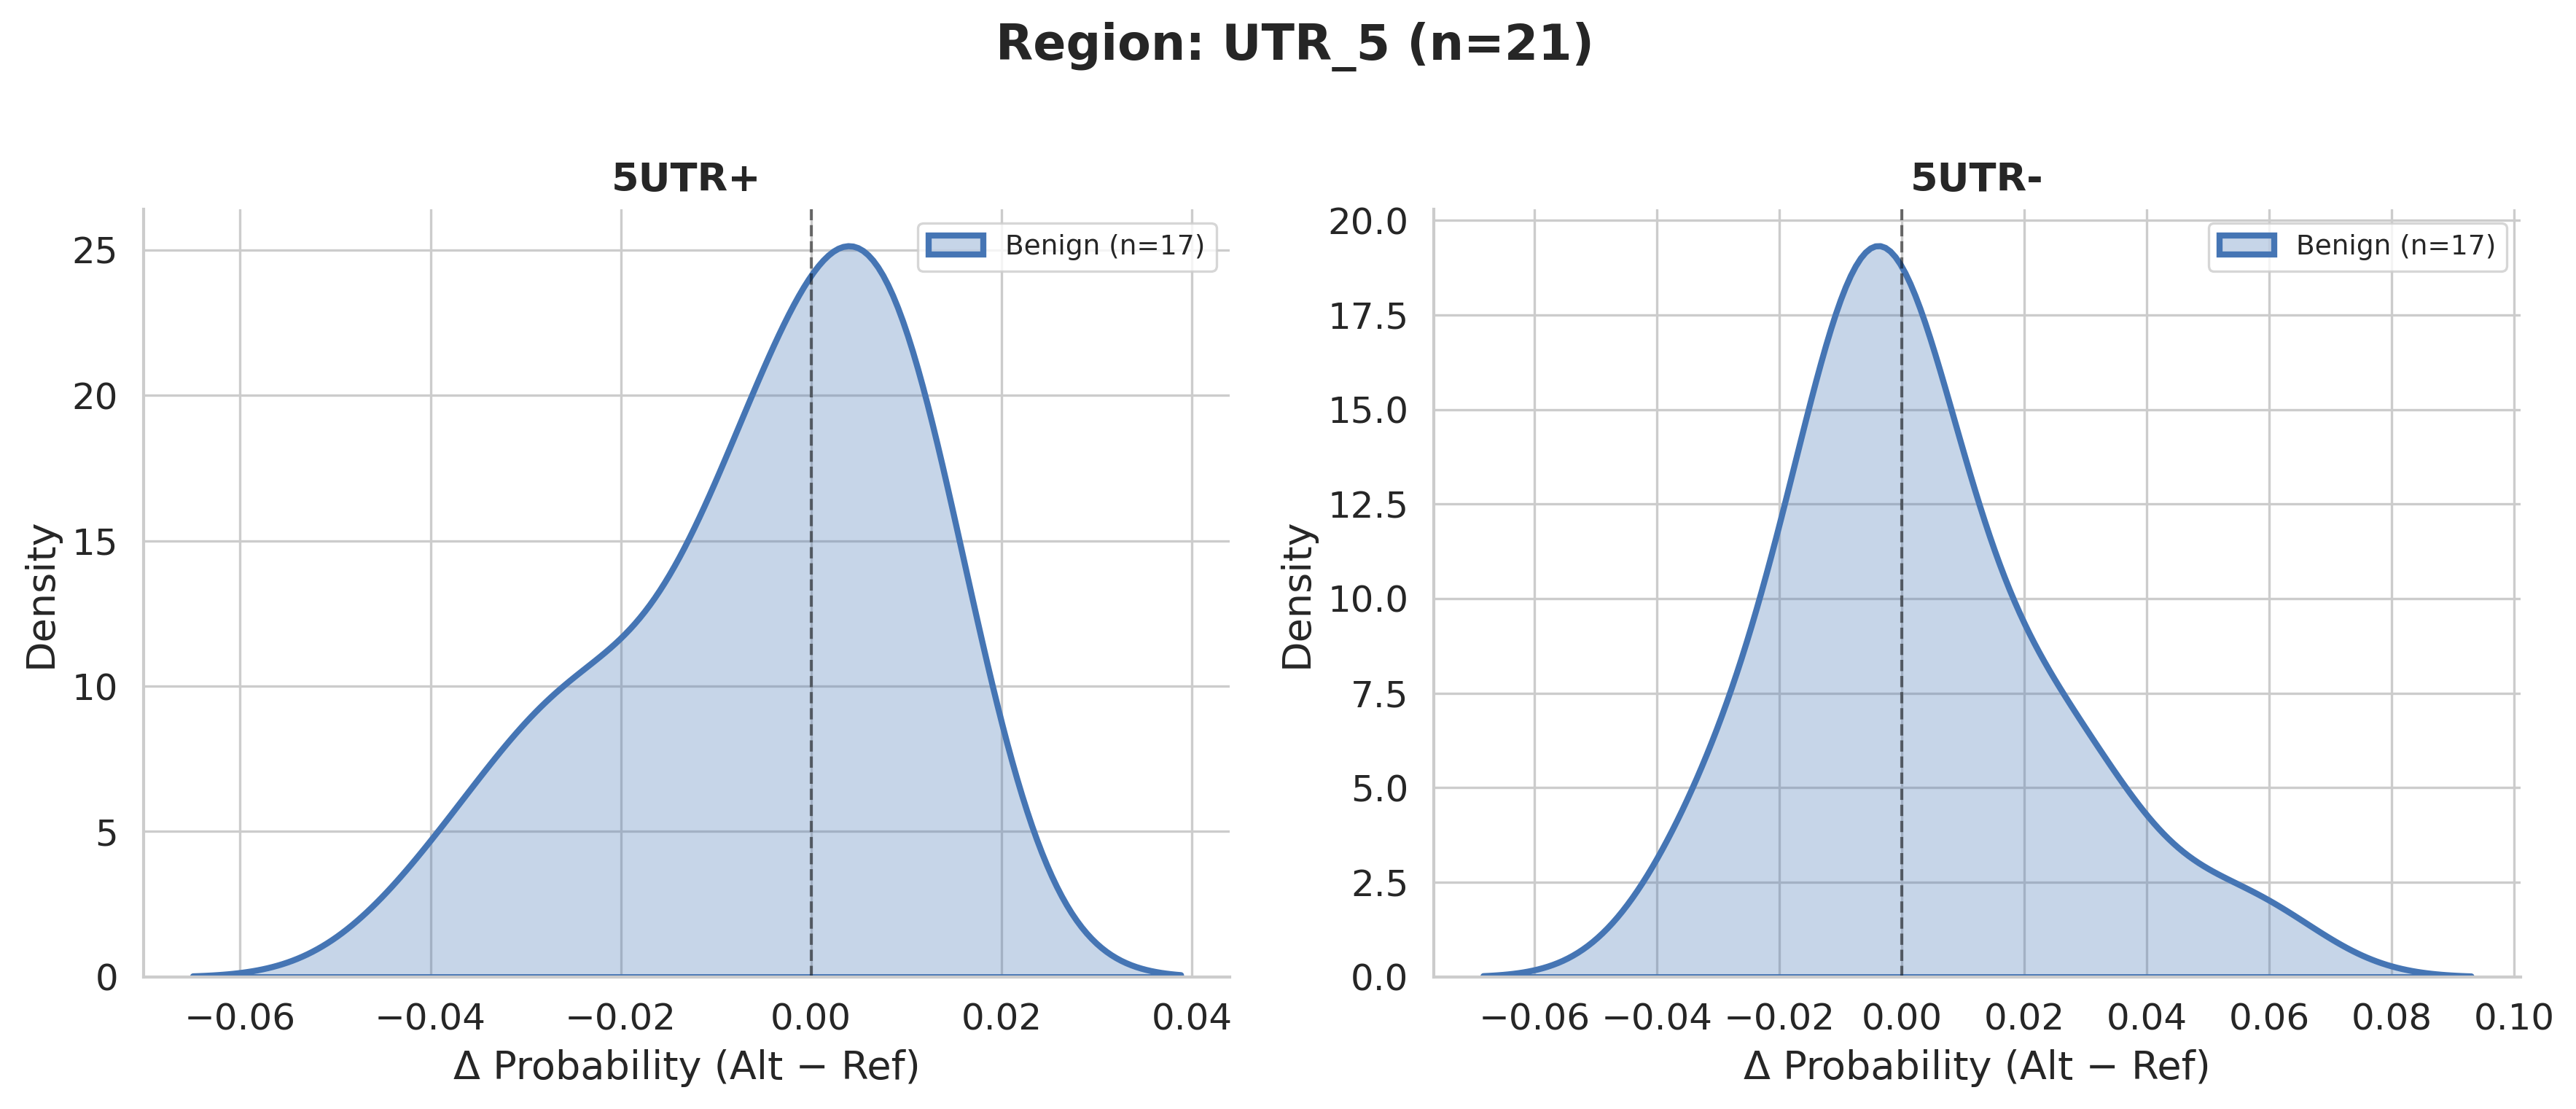

✅ Saved: kde_region_UTR_3_bed_deltas.pdf


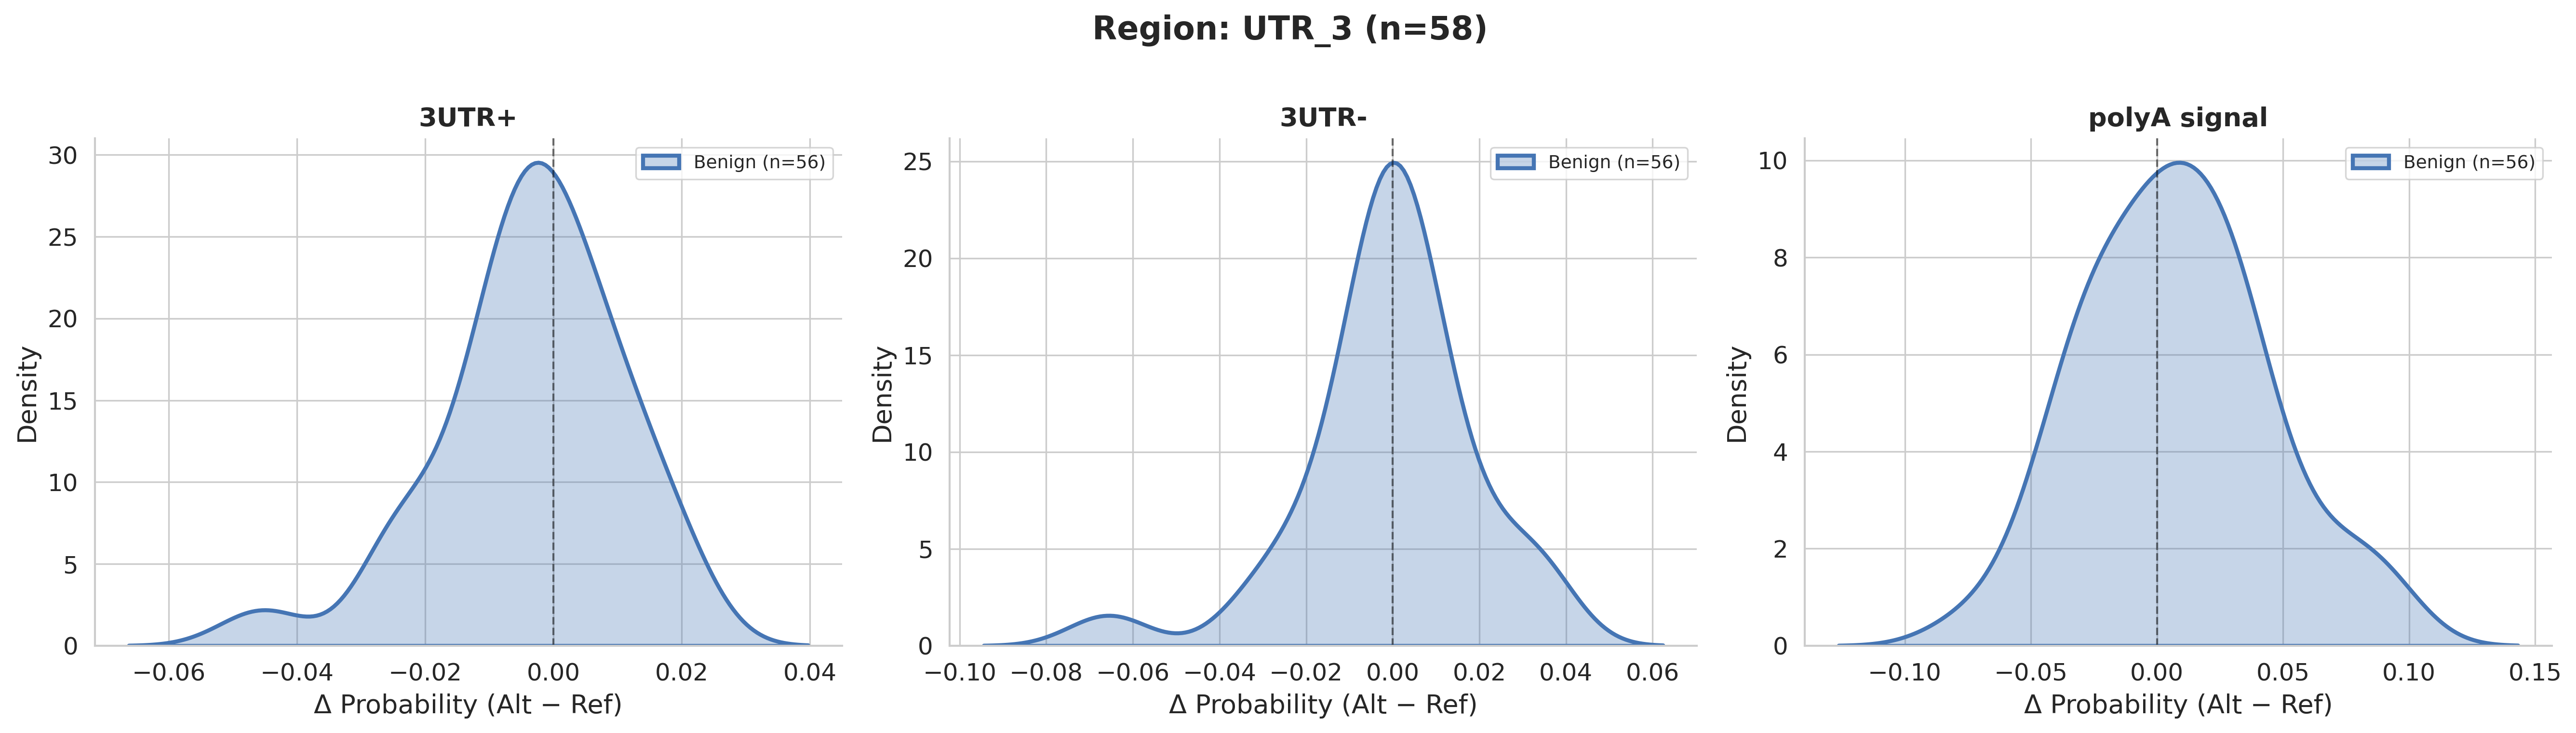

✅ Saved: kde_region_PROMOTER_bed_deltas.pdf


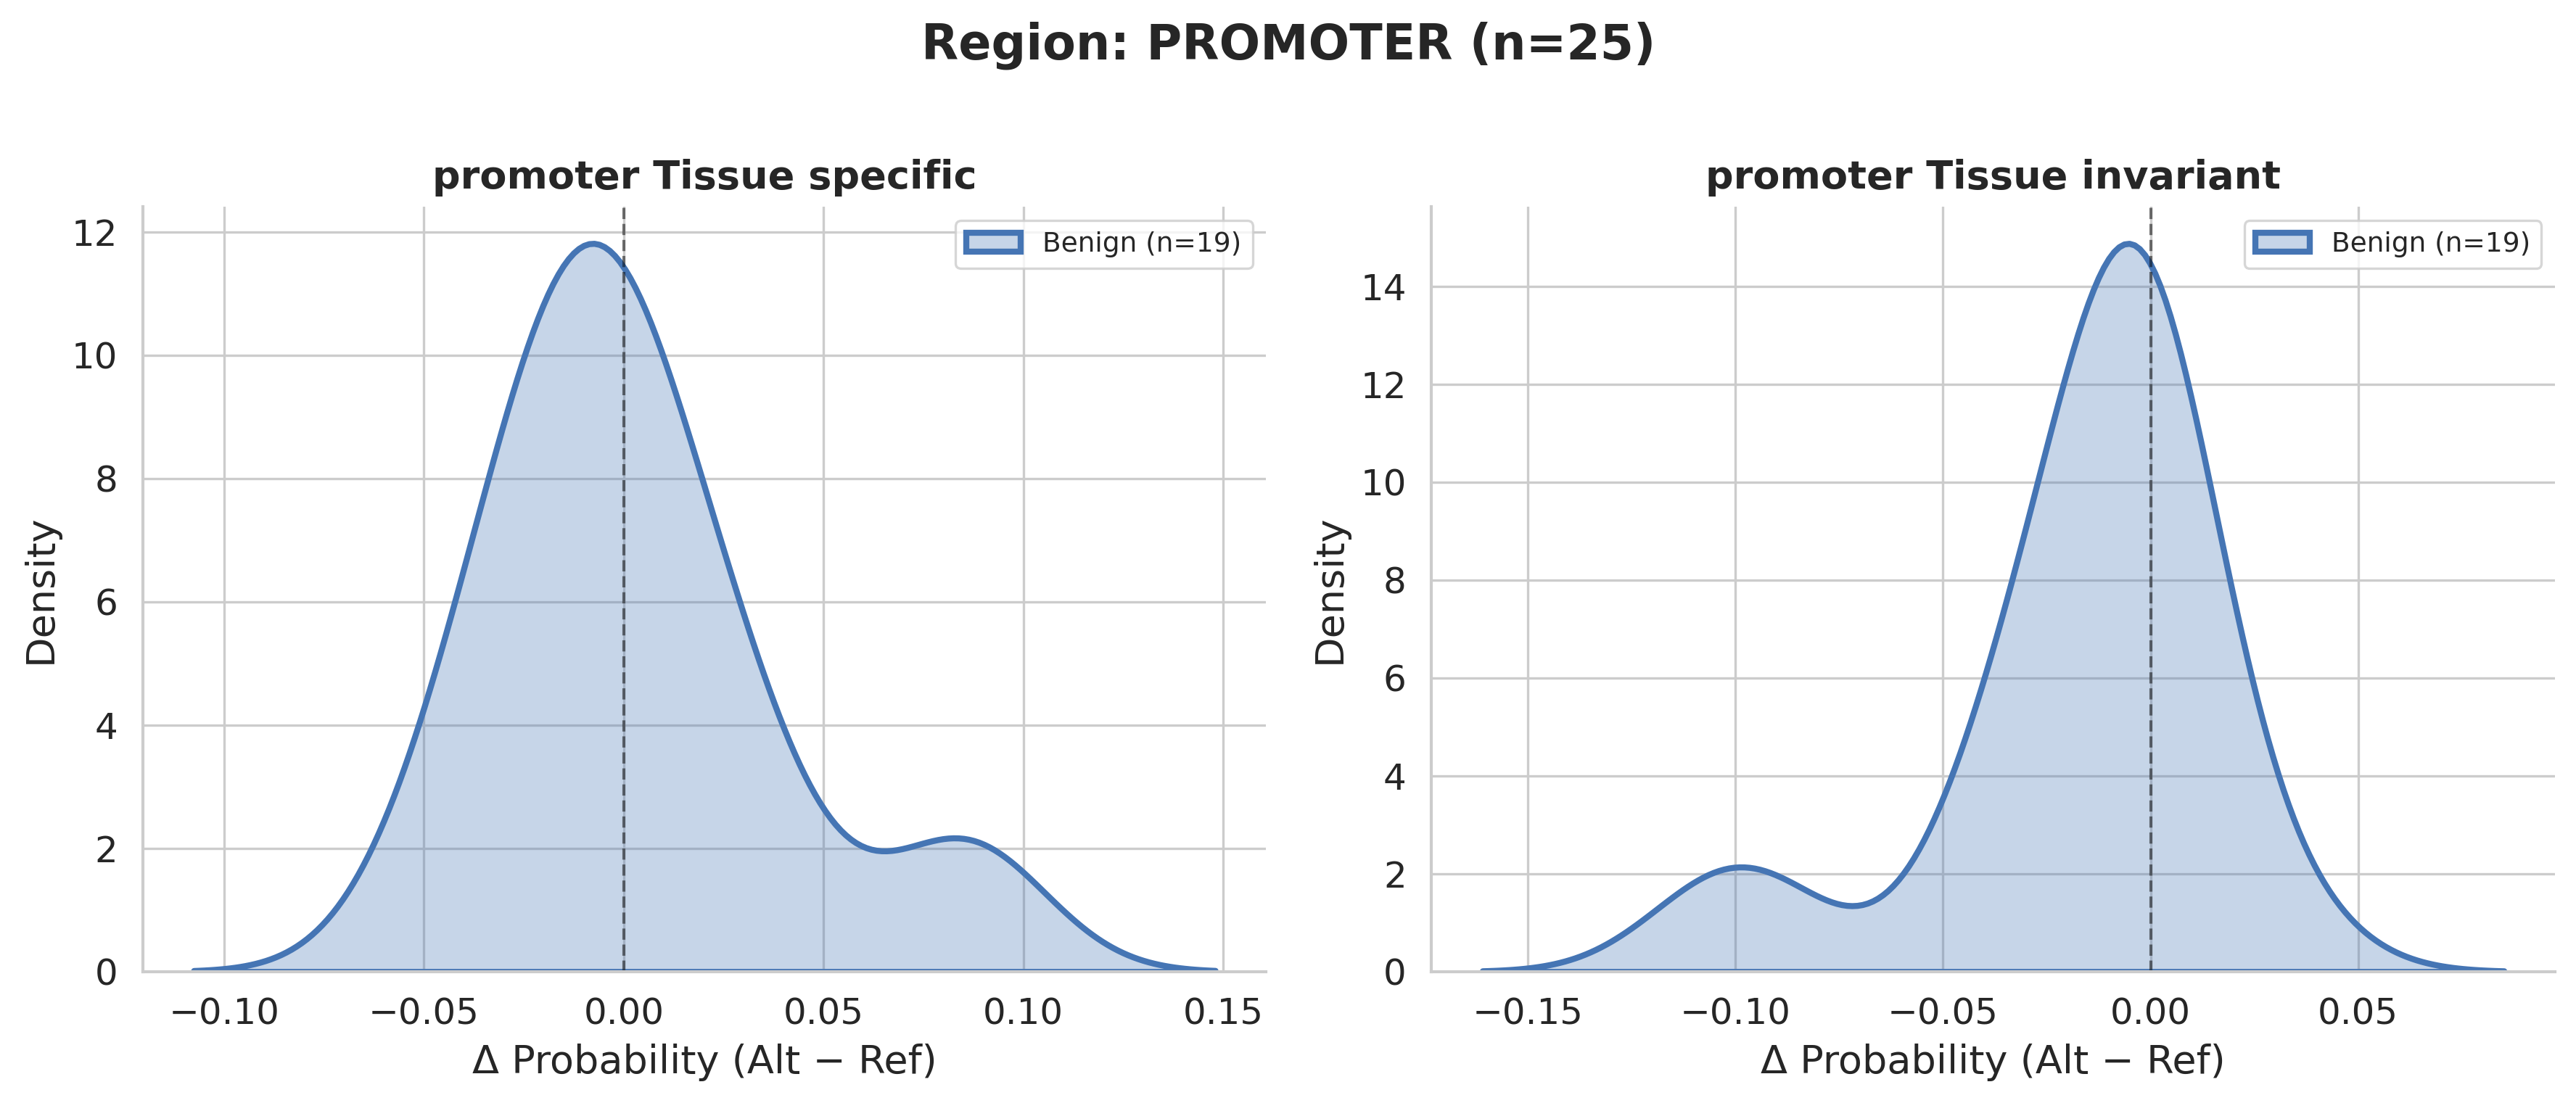

✅ Region class analysis complete


In [10]:
# ============================================================================
# ANALYZE BY REGION_CLASS (STRUCTURAL GROUPING)
# ============================================================================
print(
    "🧬 Analyzing BED deltas by region_class "
    "(structural annotation)..."
)

MIN_KDE_N = 10

# Check if region_class column exists
if "region_class" not in df.columns:
    print("⚠️  WARNING: 'region_class' column not found. Skipping region analysis.")
else:
    # Region class distribution
    region_counts = df["region_class"].value_counts()
    print("Region class distribution:")
    print(region_counts)

    # Map region_class to relevant BED columns
    REGION_BED_MAP = {
        "CODING": [
            "D_BED_exon",
            "D_BED_ORF",
            "D_BED_protein_coding_gene",
            "D_BED_start_codon",
            "D_BED_stop_codon",
        ],
        "CODING, SPLICE": [
            "D_BED_splice_donor",
            "D_BED_splice_acceptor",
            "D_BED_exon",
            "D_BED_intron",
        ],
        "SPLICE": ["D_BED_splice_donor", "D_BED_splice_acceptor", "D_BED_intron"],
        "UTR_5": ["D_BED_5UTR+", "D_BED_5UTR-"],
        "UTR_3": ["D_BED_3UTR+", "D_BED_3UTR-", "D_BED_polyA_signal"],
        "PROMOTER": [
            "D_BED_promoter_Tissue_specific",
            "D_BED_promoter_Tissue_invariant",
        ],
        "INTRONIC": ["D_BED_intron"],
    }

    # Filter to existing columns
    for region, cols in REGION_BED_MAP.items():
        REGION_BED_MAP[region] = [c for c in cols if c in BED_DELTA_COLS]

    # Plot top regions
    TOP_REGIONS = ["CODING", "CODING, SPLICE", "SPLICE", "UTR_5", "UTR_3", "PROMOTER"]
    valid_regions = [
        r
        for r in TOP_REGIONS
        if r in region_counts.index and region_counts[r] >= MIN_MATCHES_FOR_PLOT
    ]

    print(
        f"Plotting {len(valid_regions)} region classes "
        f"with >= {MIN_MATCHES_FOR_PLOT} variants"
    )

    for region in valid_regions:
        bed_cols = REGION_BED_MAP.get(region, [])

        if len(bed_cols) == 0:
            continue

        # Filter to region
        region_mask = df["region_class"] == region
        n_region = region_mask.sum()

        # Create subplots
        n_cols = min(3, len(bed_cols))
        n_rows = int(np.ceil(len(bed_cols) / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
        axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

        for i, bed_col in enumerate(bed_cols):
            ax = axes[i]

            # Filter data
            subset = df[region_mask][[bed_col, "label"]].dropna()

            if len(subset) < 10:
                ax.text(
                    0.5,
                    0.5,
                    "Insufficient data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                continue

            # Separate by label
            path_vals = subset[subset["label"] == "Pathogenic"][bed_col]
            ben_vals = subset[subset["label"] == "Benign"][bed_col]

            plot_path = len(path_vals) >= MIN_KDE_N
            plot_ben = len(ben_vals) >= MIN_KDE_N

            if not plot_path and not plot_ben:
                msg = f"Insufficient data per label (n < {MIN_KDE_N})"
                ax.text(
                    0.5,
                    0.5,
                    msg,
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                continue

            # Plot KDEs
            if plot_path:
                sns.kdeplot(
                    data=path_vals,
                    ax=ax,
                    label=f"Pathogenic (n={len(path_vals)})",
                    color=LABEL_COLORS["Pathogenic"],
                    fill=True,
                    alpha=0.3,
                    linewidth=2,
                )
            if plot_ben:
                sns.kdeplot(
                    data=ben_vals,
                    ax=ax,
                    label=f"Benign (n={len(ben_vals)})",
                    color=LABEL_COLORS["Benign"],
                    fill=True,
                    alpha=0.3,
                    linewidth=2,
                )

            ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

            bed_label = bed_col.replace("D_BED_", "").replace("_", " ")
            ax.set_xlabel("Δ Probability (Alt − Ref)", fontsize=13)
            ax.set_ylabel("Density", fontsize=13)
            ax.set_title(f"{bed_label}", fontsize=13, fontweight="bold")
            ax.legend(frameon=True, loc="best", fontsize=9)

        # Hide unused
        for j in range(len(bed_cols), len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(
            f"Region: {region} (n={n_region})", fontsize=16, fontweight="bold", y=1.01
        )
        plt.tight_layout()

        # Save
        safe_region = region.replace(",", "").replace(" ", "_")
        fig_path = FIG_DIR / f"kde_region_{safe_region}_bed_deltas.pdf"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {fig_path.name}")
        plt.show()

    print("✅ Region class analysis complete")


🧠 Analyzing MLM features across full dataset (not regex-filtered)...
✅ Found 4 / 4 MLM features: ['LLR', 'MLM_Delta', 'MLM_KL_mean', 'MLM_KL_max']
✅ Saved: kde_mlm_features_full_dataset.pdf


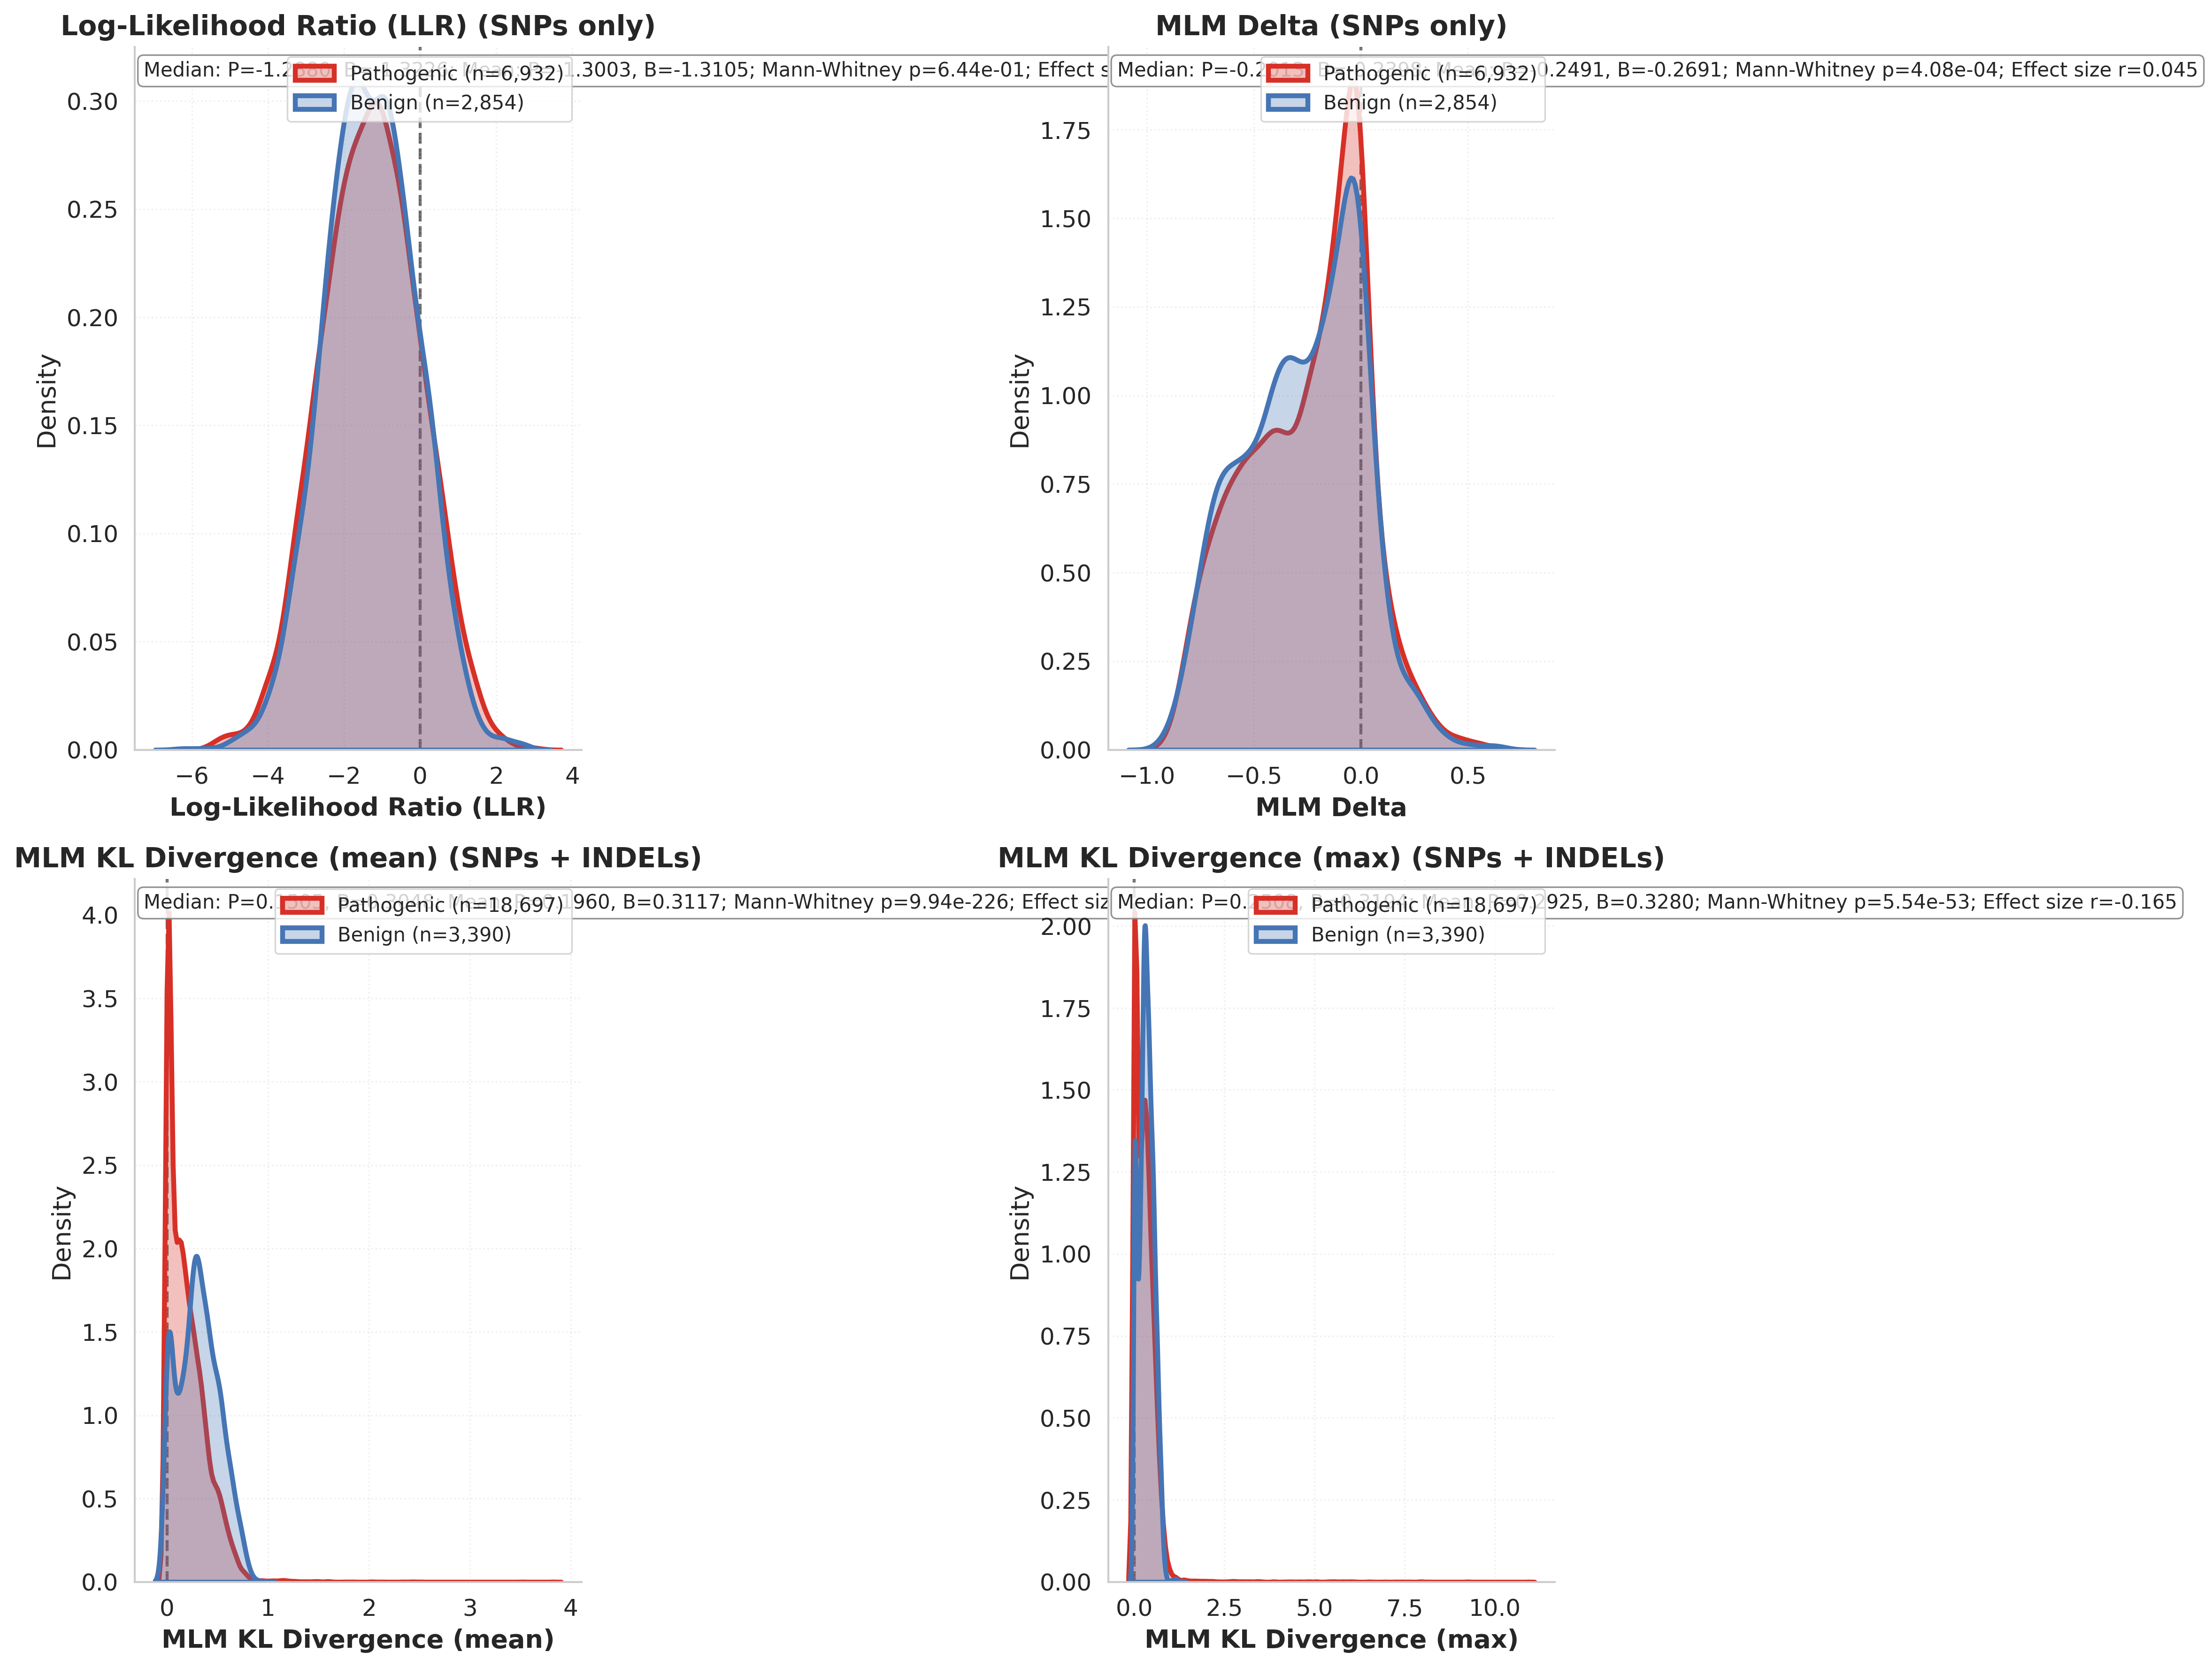

✅ MLM feature analysis complete


In [11]:
# ============================================================================
# MLM FEATURE DISTRIBUTIONS (FULL DATASET)
# ============================================================================
print(
    "🧠 Analyzing MLM features across full dataset "
    "(not regex-filtered)..."
)

MIN_KDE_N = 10

# Core MLM features to analyze
MLM_FEATURES = {
    "LLR": {
        "label": "Log-Likelihood Ratio (LLR)",
        "description": "log(P(ALT)/P(REF)) — SNPs only",
        "snp_only": True,
    },
    "MLM_Delta": {
        "label": "MLM Delta",
        "description": "P(ALT) − P(REF) — SNPs only",
        "snp_only": True,
    },
    "MLM_KL_mean": {
        "label": "MLM KL Divergence (mean)",
        "description": "Mean KL(alt || ref) over variant span",
        "snp_only": False,
    },
    "MLM_KL_max": {
        "label": "MLM KL Divergence (max)",
        "description": "Max KL(alt || ref) over variant span",
        "snp_only": False,
    },
}

# Check which features exist
existing_mlm = {feat: info for feat, info in MLM_FEATURES.items() if feat in df.columns}

if len(existing_mlm) == 0:
    print("⚠️  WARNING: No MLM features found in dataset")
else:
    print(
        f"✅ Found {len(existing_mlm)} / {len(MLM_FEATURES)} MLM features: "
        f"{list(existing_mlm.keys())}"
    )

    # Create 2×2 subplot grid
    n_features = len(existing_mlm)
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]

    for i, (feat, info) in enumerate(existing_mlm.items()):
        ax = axes[i]

        # Filter data based on SNP-only requirement
        if info["snp_only"]:
            plot_df = df[df["variant_type"] == "SNP"][[feat, "label"]].dropna()
            title_suffix = " (SNPs only)"
        else:
            plot_df = df[[feat, "label"]].dropna()
            title_suffix = " (SNPs + INDELs)"

        if len(plot_df) == 0:
            ax.text(
                0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes
            )
            ax.set_title(info["label"])
            continue

        # Separate by label
        path_vals = plot_df[plot_df["label"] == "Pathogenic"][feat]
        ben_vals = plot_df[plot_df["label"] == "Benign"][feat]

        plot_path = len(path_vals) >= MIN_KDE_N
        plot_ben = len(ben_vals) >= MIN_KDE_N

        if not plot_path and not plot_ben:
            msg = f"Insufficient data per label (n < {MIN_KDE_N})"
            ax.text(
                0.5,
                0.5,
                msg,
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(info["label"])
            continue

        # Plot KDEs
        if plot_path:
            sns.kdeplot(
                data=path_vals,
                ax=ax,
                label=f"Pathogenic (n={len(path_vals):,})",
                color=LABEL_COLORS["Pathogenic"],
                fill=True,
                alpha=0.3,
                linewidth=2.5,
            )

        if plot_ben:
            sns.kdeplot(
                data=ben_vals,
                ax=ax,
                label=f"Benign (n={len(ben_vals):,})",
                color=LABEL_COLORS["Benign"],
                fill=True,
                alpha=0.3,
                linewidth=2.5,
            )

        # Add vertical line at 0 (or median if far from 0)
        ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.6, zorder=0)

        # Compute statistics
        if plot_path and plot_ben:
            # Mann-Whitney U test
            stat, pval = stats.mannwhitneyu(
                path_vals, ben_vals, alternative="two-sided"
            )

            # Medians and means
            med_path = path_vals.median()
            med_ben = ben_vals.median()
            mean_path = path_vals.mean()
            mean_ben = ben_vals.mean()

            # Effect size (rank-biserial)
            auc = stat / (len(path_vals) * len(ben_vals))
            effect = 2 * auc - 1

            # Annotation box
            stats_text = (
                f"Median: P={med_path:.4f}, B={med_ben:.4f}; "
                f"Mean: P={mean_path:.4f}, B={mean_ben:.4f}; "
                f"Mann-Whitney p={pval:.2e}; Effect size r={effect:.3f}"
            )

            ax.text(
                0.02,
                0.98,
                stats_text,
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment="top",
                bbox=dict(
                    boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray"
                ),
            )

        # Labels
        ax.set_xlabel(info["label"], fontsize=13, fontweight="bold")
        ax.set_ylabel("Density", fontsize=13)
        ax.set_title(f"{info['label']}{title_suffix}", fontsize=14, fontweight="bold")
        ax.legend(frameon=True, loc="upper right", fontsize=10)
        ax.grid(True, alpha=0.3, linestyle=":")

    # Hide unused subplots
    for j in range(len(existing_mlm), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    # Save
    fig_path = FIG_DIR / "kde_mlm_features_full_dataset.pdf"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"✅ Saved: {fig_path.name}")
    plt.show()

    print("✅ MLM feature analysis complete")


In [12]:
# ============================================================================
# EXPORT SUMMARY STATISTICS & FIGURES
# ============================================================================
print("💾 Exporting summary statistics and figure inventory...\n")
print("=" * 90)

# Summary statistics table
summary_stats = []

# Consequence group stats
if "match_df" in locals():
    print("📊 Consequence Group Summary:")
    print(match_df.to_string(index=False))
    print()

    # Save to CSV
    stats_path = FIG_DIR / "consequence_group_match_counts.csv"
    match_df.to_csv(stats_path, index=False)
    print(f"✅ Saved: {stats_path.name}\n")

# MLM feature summary
if len(existing_mlm) > 0:
    print("📊 MLM Feature Summary Statistics:\n")

    mlm_summary = []
    for feat, info in existing_mlm.items():
        if info["snp_only"]:
            feat_df = df[df["variant_type"] == "SNP"][[feat, "label"]].dropna()
        else:
            feat_df = df[[feat, "label"]].dropna()

        if len(feat_df) == 0:
            continue

        path_vals = feat_df[feat_df["label"] == "Pathogenic"][feat]
        ben_vals = feat_df[feat_df["label"] == "Benign"][feat]

        if len(path_vals) > 1 and len(ben_vals) > 1:
            stat, pval = stats.mannwhitneyu(
                path_vals, ben_vals, alternative="two-sided"
            )
            auc = stat / (len(path_vals) * len(ben_vals))
            effect = 2 * auc - 1

            mlm_summary.append(
                {
                    "Feature": feat,
                    "N_Pathogenic": len(path_vals),
                    "N_Benign": len(ben_vals),
                    "Median_Pathogenic": path_vals.median(),
                    "Median_Benign": ben_vals.median(),
                    "Mean_Pathogenic": path_vals.mean(),
                    "Mean_Benign": ben_vals.mean(),
                    "Mann_Whitney_p": pval,
                    "Effect_Size_r": effect,
                }
            )

    if mlm_summary:
        mlm_df = pd.DataFrame(mlm_summary)
        print(mlm_df.to_string(index=False))

        # Save
        mlm_path = FIG_DIR / "mlm_feature_statistics.csv"
        mlm_df.to_csv(mlm_path, index=False)
        print(f"\n✅ Saved: {mlm_path.name}")

# List all generated figures
print("\n" + "=" * 90)
print("📁 Generated Figures:\n")

fig_files = sorted(FIG_DIR.glob("*.pdf"))
for i, fig_file in enumerate(fig_files, 1):
    size_kb = fig_file.stat().st_size / 1024
    print(f"  {i:2d}. {fig_file.name} ({size_kb:.1f} KB)")

print(f"\n✅ Total: {len(fig_files)} figure files in {FIG_DIR}/")
print("=" * 90)

# Final summary
print("\n" + "🎉" * 30)
print("✅ EDA ANALYSIS COMPLETE")
print("🎉" * 30)
print(f"""
Summary:
  • Variants analyzed: {len(df):,} ({df["variant_type"].value_counts().to_dict()})
  • Consequence groups: {len(CONSEQUENCE_GROUPS)}
  • BED delta columns: {len(BED_DELTA_COLS)}
  • MLM features: {len(existing_mlm)}
  • Figures generated: {len(fig_files)}
  • Output directory: {FIG_DIR}/
  
All figures are publication-ready (300 DPI, PDF format).
""")

💾 Exporting summary statistics and figure inventory...

📊 Consequence Group Summary:
                      Group  Total  Pathogenic  Benign  Pct_Dataset  BED_cols
Missense / Protein Function  10898       10319     579    49.341241         4
          Truncation / Stop  10764       10375     389    48.734550         4
                 Frameshift   7864        7858       6    35.604654         3
                UTR / PolyA   5098        5072      26    23.081451         5
                   Splicing   1969        1845     124     8.914746         5
      Regulatory / Promoter   1245        1241       4     5.636800         5
    Start-loss / Initiation    309         306       3     1.399013         4

✅ Saved: consequence_group_match_counts.csv

📊 MLM Feature Summary Statistics:

    Feature  N_Pathogenic  N_Benign  Median_Pathogenic  Median_Benign  Mean_Pathogenic  Mean_Benign  Mann_Whitney_p  Effect_Size_r
        LLR          6932      2854          -1.288044      -1.322649        -1

In [13]:
# ============================================================================
# OPTIONAL: INTERACTIVE EXPLORATION
# ============================================================================
# Uncomment and customize to explore specific consequence × BED combinations

# Example: Deep dive into Splicing variants
# group = 'Splicing'
# bed_col = 'D_BED_splice_donor'
#
# if group in CONSEQUENCE_GROUPS and bed_col in CONSEQUENCE_GROUPS[group]['bed_cols']:
#     fig, ax = plt.subplots(figsize=(10, 6))
#     plot_consequence_bed_kde(df, group, CONSEQUENCE_GROUPS[group], bed_col,
#                             ax=ax, min_matches=10, add_stats=True)
#     plt.tight_layout()
#     plt.show()
#
#     # Show sample variants
#     subset = df[CONSEQUENCE_GROUPS[group]['mask']][[
#         'chrom', 'pos', 'ref', 'alt', 'label', bed_col, 'FullRationale'
#     ]].sort_values(bed_col, ascending=False)
#
#     print(f"\nTop 5 {group} variants by {bed_col}:")
#     print(subset.head(5))

print(
    "💡 Tip: Uncomment the code above to interactively explore specific consequence groups"
)

💡 Tip: Uncomment the code above to interactively explore specific consequence groups
